<a href="https://www.kaggle.com/code/jakomina/h-logic?scriptVersionId=311696217" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [34]:
!pip install  matplotlib qiskit qiskit-aer 

In [35]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import math
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/gemma-4-good-hackathon/NOTE.md


**Runs a quantum experiment based on given parameters for particle classification
    and quantum circuit simulation.**

    Args:
        n_param (int): Integer parameter for parity and quasiperiod calculations.
        phi_param (float): Golden ratio related parameter for calculations and RZ/RY gates.

In [36]:
def run_quantum_experiment(n_param, phi_param):
    # Lazy Qiskit imports — only needed for circuit simulation
    from qiskit import QuantumCircuit
    from qiskit.visualization import plot_histogram, plot_bloch_multivector
    from qiskit.quantum_info import Statevector
    import matplotlib.pyplot as plt

    # --- Particle Classification ---
    # Constants for particle classification
    PI = np.pi
    COS = math.cos

    # Operators  (O_n = cos(π·n) · cos(π·φ·n))
    parity = COS(PI * n_param)
    quasiperiod = COS(PI * phi_param * n_param)
    golden = parity * quasiperiod

    # Corrected function to classify particle type
    def classify_particle(golden_val, quasiperiod_val):
        core_value = golden_val * quasiperiod_val
        if core_value < 0.1:
            return "fermionic"
        elif core_value > 0.1:
            return "bosonic"
        else:
            return "unknown"

    particle_type = classify_particle(golden, quasiperiod)
    print("--- Particle Classification Results ---")
    print("  Parity:", parity)
    print("  Quasiperiod:", quasiperiod)
    print("  Chiral:", golden)
    print(f"  Particle Type: {particle_type} → {golden + quasiperiod}")
    print("\n" + "="*40 + "\n")

    # --- Part 2: Quantum Circuit Simulation ---
    print("--- Quantum Circuit Simulation Results ---")

    qc = QuantumCircuit(3, 4)

    qc.h(0)
    qc.h(1)
    qc.h(2)

    rotation_angle = COS(PI * phi_param)
    qc.rz(rotation_angle, 0)
    qc.ry(rotation_angle, 1)
    qc.rx(theta=0, qubit=2)

    qc.cswap(0, 2, 1)
    qc.ccx(2, 1, 0)

    print("\n  Quantum Circuit Diagram (before measurement):")
    print(qc.draw())
    print(f"  Operation counts: {qc.count_ops()}")

    psi = Statevector.from_instruction(qc)
    print("\n  State Vector (Pure Data):")
    print(psi.data)

    print("\n  State Vector (Text Representation):")
    print(psi.draw('text'))

    probs_dict = psi.probabilities_dict()
    print("\n  Probabilities per State:", probs_dict)

    print("\n  Generating Probability Histogram...")
    plot_histogram(probs_dict, title="Probabilities per State").show()
    plt.close()

    print("\n  Generating Bloch Sphere Representation...")
    plot_bloch_multivector(psi, title="Bloch Sphere Representation").show()
    plt.close()

    probs_q0 = psi.probabilities([0])
    print(f"\n  Probabilities of Qubit 0: {probs_q0}")
    probs_q1 = psi.probabilities([1])
    print(f"  Probabilities of Qubit 1: {probs_q1}")
    probs_q2 = psi.probabilities([2])
    print(f"  Probabilities of Qubit 2: {probs_q2}")

    qc.measure(qubit=0, cbit=0)
    qc.measure(qubit=1, cbit=2)
    qc.measure(qubit=2, cbit=1)

    print("\n  Quantum Circuit Diagram (after measurement):")
    print(qc.draw())
    print("\n" + "="*40 + "\n")


# Metriplex Momentum Oracle
## Mechanism: Energy Profiling for Simon's Algorithm

**Core Concept:**

### The oracle maps classical momentum states p ∈ [1..6] to 2D energy vectors, establishing a 2-to-1 function that Simon's algorithm can exploit.

**Energy Profiling:**

- Group A (p ∈ {1,2,3}) → (1, 0)  [Normalized energy ≈ 0.45]
- Group B (p ∈ {4,5,6}) → (0, 1)  [Normalized energy ≈ 0.45]

### The "collision" structure reveals hidden symmetry:

> p ⊕ (p+3) = 3 mod 6.

In [37]:
import numpy as np
from typing import Tuple, Dict, List, Callable, Optional
from dataclasses import dataclass, field
from enum import Enum
import warnings


class EnergyProfile(Enum):
    """Predefined energy normalization profiles."""
    LINEAR = "linear"
    QUADRATIC = "quadratic"
    METRIPLEX = "metriplex"
    CUSTOM = "custom"


@dataclass
class MetriplexConfig:
    """Configuration for metriplex oracle."""
    momentum_range: Tuple[int, int] = (1, 6)
    energy_profile: EnergyProfile = EnergyProfile.METRIPLEX
    normalization_target: float = 0.45
    collision_groups: Optional[Dict[str, List[int]]] = None

    def __post_init__(self):
        if self.collision_groups is None:
            self.collision_groups = {
                'A': [1, 2, 3],
                'B': [4, 5, 6]
            }


class MetriplexOracle:
    """
    Metriplex momentum oracle for second quantization.

    Maps momentum states to energy vectors establishing a hidden 2-to-1
    function. Simon's algorithm discovers: momentum pairs differing by 3
    collide. (Symplectic component: phase shifts; Metric component: energy
    relaxation toward normalization_target attractor.)
    """

    def __init__(self, config: MetriplexConfig = None):
        if config is None:
            config = MetriplexConfig()
        self.config = config
        self.p_min, self.p_max = config.momentum_range
        self._build_energy_map()
        self._build_collision_map()

    def _build_energy_map(self):
        self.energy_map = {}
        for p in range(self.p_min, self.p_max + 1):
            if self.config.energy_profile == EnergyProfile.LINEAR:
                raw_energy = p / self.p_max
            elif self.config.energy_profile == EnergyProfile.QUADRATIC:
                raw_energy = (p / self.p_max) ** 2
            elif self.config.energy_profile == EnergyProfile.METRIPLEX:
                alpha = 1.2
                raw_energy = self.config.normalization_target * (p / self.p_max) ** alpha
            else:
                raise ValueError(f"Unknown energy profile: {self.config.energy_profile}")
            self.energy_map[p] = raw_energy

        mean_energy = np.mean([self.energy_map[p] for p in range(self.p_min, self.p_max + 1)])
        if abs(mean_energy - self.config.normalization_target) > 0.01:
            warnings.warn(
                f"Mean energy {mean_energy:.4f} deviates from target "
                f"{self.config.normalization_target:.4f}"
            )

    def _build_collision_map(self):
        self.collision_map = {}
        self.output_groups = {}
        for group_name, momenta in self.config.collision_groups.items():
            for p in momenta:
                self.collision_map[p] = group_name
            group_index = list(self.config.collision_groups.keys()).index(group_name)
            n_groups = len(self.config.collision_groups)
            output_vec = np.zeros(n_groups)
            output_vec[group_index] = 1.0
            self.output_groups[group_name] = output_vec

    def _compute_symmetry_string(self) -> int:
        group_lists = list(self.config.collision_groups.values())
        xor_accumulator = 0
        for group in group_lists:
            for i, p1 in enumerate(group):
                for p2 in group[i+1:]:
                    xor_accumulator |= (p1 ^ p2)
        return xor_accumulator

    def forward(self, momentum: int) -> Tuple[str, np.ndarray, float]:
        """Evaluate oracle at given momentum state."""
        if momentum < self.p_min or momentum > self.p_max:
            raise ValueError(f"Momentum {momentum} out of range [{self.p_min}, {self.p_max}]")
        group = self.collision_map[momentum]
        output_vec = self.output_groups[group]
        energy = self.energy_map[momentum]
        return group, output_vec, energy

    def collide_pair(self, p1: int, p2: int) -> bool:
        return self.collision_map[p1] == self.collision_map[p2]

    def get_collision_partners(self, p: int) -> List[int]:
        group = self.collision_map[p]
        return self.config.collision_groups[group]

    def symmetry_string(self) -> int:
        return self._compute_symmetry_string()

    def to_hilbert_oracle(self, fock_basis) -> Callable:
        """Convert classical oracle to quantum operator for Hilbert space."""
        def quantum_oracle(state_vector: np.ndarray) -> np.ndarray:
            result = state_vector.copy()
            for idx, occupation in enumerate(fock_basis.basis_states):
                effective_momentum = self._occupation_to_momentum(occupation)
                energy = self.energy_map[effective_momentum]
                phase_shift = np.exp(2j * np.pi * energy)
                result[idx] *= phase_shift
            return result
        return quantum_oracle

    def _occupation_to_momentum(self, occupation: Tuple[int, ...]) -> int:
        total_occ = sum(occupation)
        range_size = self.p_max - self.p_min + 1
        p = (total_occ % range_size) + self.p_min
        return p

    def get_oracle_info(self) -> Dict:
        return {
            'momentum_range': self.config.momentum_range,
            'n_groups': len(self.config.collision_groups),
            'collision_groups': {k: v for k, v in self.config.collision_groups.items()},
            'symmetry_string': self.symmetry_string(),
            'energy_profile': self.config.energy_profile.value,
            'normalization_target': self.config.normalization_target,
            'energy_map': {p: self.energy_map[p] for p in range(self.p_min, self.p_max + 1)},
            'collision_structure': {p: self.collision_map[p] for p in range(self.p_min, self.p_max + 1)}
        }


class H7Conservation:
    """
    Mechanism I: H7 Entanglement Conservation

    In 3-qubit Hilbert space (8 basis states 0-7), states are paired
    by the rule: x ↔ (7 ⊕ x). This conservation law is fundamental.
    """

    CONSERVATION_CONSTANT = 7

    @staticmethod
    def partner_state(state: int) -> int:
        if not (0 <= state <= 7):
            raise ValueError("State must be in [0, 7]")
        return H7Conservation.CONSERVATION_CONSTANT ^ state

    @staticmethod
    def verify_pairing(state_a: int, state_b: int) -> bool:
        return state_b == H7Conservation.partner_state(state_a)

    @staticmethod
    def pairing_table() -> Dict[int, int]:
        return {i: H7Conservation.partner_state(i) for i in range(8)}

    @staticmethod
    def verify_conservation_invariant(state_vector: np.ndarray, threshold: float = 1e-6) -> bool:
        if len(state_vector) != 8:
            raise ValueError("State vector must be 8-dimensional (3-qubit Hilbert space)")
        for i in range(8):
            if abs(state_vector[i]) > threshold:
                partner = H7Conservation.partner_state(i)
                if abs(state_vector[partner]) < threshold:
                    return False
        return True


# Fock Space Foundation ModuleFramework:
**Second Quantization for Metriplex Dynamics**

- **The Fock SpaceRepresents the physical state $P$ and $V$ of probability densities.**
- **class OccupationMode(Enum):**
Enumerates the particle occupation types.
- **class FockConfig:**
Dataclass to initialize the photon/particle limits.
- **class FockStateVector:** Functions to manipulate mathematical kets.
- **class FockBasis:**
Generator of the combinatorial space (the possible states of the lattice).
- **def fock_ground_state(fock_basis) and fock_single_photon():**
Helper functions to instantiate basis states.

In [38]:
class OccupationMode(Enum):
    """Enumeration of occupation number modes in Fock space."""
    BOSONIC = "bosonic"
    FERMIONIC = "fermionic"


@dataclass
class FockConfig:
    """Configuration for Fock space instantiation."""
    n_modes: int = 3
    n_max: int = 3
    mode_type: OccupationMode = OccupationMode.BOSONIC
    use_gray_code: bool = True


class FockBasis:
    """
    Fock space representation with second quantization operators.
    dim(H_Fock) = (n_max + 1)^n_modes
    """

    def __init__(self, config: FockConfig = None):
        if config is None:
            config = FockConfig()
        self.config = config
        self.n_modes = config.n_modes
        self.n_max = config.n_max
        self.dim = (config.n_max + 1) ** config.n_modes
        self._build_basis()
        self._precompute_operators()

    def _build_basis(self):
        basis_states = []
        for occupation in np.ndindex(*[self.n_max + 1] * self.n_modes):
            basis_states.append(occupation)
        self.basis_states = np.array(basis_states)
        assert len(self.basis_states) == self.dim
        self.state_to_index = {tuple(state): i for i, state in enumerate(self.basis_states)}
        self.index_to_state = {i: tuple(state) for i, state in enumerate(self.basis_states)}

    def _precompute_operators(self):
        self.creation_ops = {}
        self.annihilation_ops = {}
        for mode in range(self.n_modes):
            self.creation_ops[mode] = self._build_creation_op(mode)
            self.annihilation_ops[mode] = self._build_annihilation_op(mode)

    def _build_creation_op(self, mode: int) -> np.ndarray:
        op = np.zeros((self.dim, self.dim), dtype=complex)
        for i, state in enumerate(self.basis_states):
            state_list = list(state)
            if state_list[mode] < self.n_max:
                new_occupation = state_list[mode] + 1
                amplitude = np.sqrt(new_occupation)
                state_list[mode] = new_occupation
                j = self.state_to_index[tuple(state_list)]
                op[j, i] = amplitude
        return op

    def _build_annihilation_op(self, mode: int) -> np.ndarray:
        op = np.zeros((self.dim, self.dim), dtype=complex)
        for i, state in enumerate(self.basis_states):
            state_list = list(state)
            if state_list[mode] > 0:
                old_occupation = state_list[mode]
                amplitude = np.sqrt(old_occupation)
                state_list[mode] = old_occupation - 1
                j = self.state_to_index[tuple(state_list)]
                op[j, i] = amplitude
        return op

    def get_creation_op(self, mode: int) -> np.ndarray:
        if mode not in self.creation_ops:
            raise ValueError(f"Mode {mode} out of range [0, {self.n_modes-1}]")
        return self.creation_ops[mode].copy()

    def get_annihilation_op(self, mode: int) -> np.ndarray:
        if mode not in self.annihilation_ops:
            raise ValueError(f"Mode {mode} out of range [0, {self.n_modes-1}]")
        return self.annihilation_ops[mode].copy()

    def number_operator(self, mode: int) -> np.ndarray:
        a_dag = self.get_creation_op(mode)
        a = self.get_annihilation_op(mode)
        return a_dag @ a

    def total_number_operator(self) -> np.ndarray:
        N_total = np.zeros((self.dim, self.dim), dtype=complex)
        for mode in range(self.n_modes):
            N_total += self.number_operator(mode)
        return N_total

    def state_vector(self, occupation: Tuple[int, ...]) -> np.ndarray:
        if len(occupation) != self.n_modes:
            raise ValueError(f"Occupation must have {self.n_modes} elements")
        if any(n > self.n_max for n in occupation):
            raise ValueError(f"Occupation exceeds n_max = {self.n_max}")
        vec = np.zeros(self.dim, dtype=complex)
        idx = self.state_to_index[tuple(occupation)]
        vec[idx] = 1.0
        return vec

    def to_gray_code(self, state_index: int) -> int:
        return state_index ^ (state_index >> 1)

    def from_gray_code(self, gray: int) -> int:
        mask = gray
        while mask:
            mask >>= 1
            gray ^= mask
        return gray

    def occupation_to_binary(self, occupation: Tuple[int, ...]) -> str:
        state_index = self.state_to_index[tuple(occupation)]
        if self.config.use_gray_code:
            binary_rep = self.to_gray_code(state_index)
        else:
            binary_rep = state_index
        return format(binary_rep, f'0{self.n_modes * 2}b')

    def get_basis_info(self) -> Dict:
        return {
            'dimension': self.dim,
            'n_modes': self.n_modes,
            'n_max_per_mode': self.n_max,
            'total_occupation_max': self.n_max * self.n_modes,
            'basis_states': self.basis_states.tolist(),
            'use_gray_code': self.config.use_gray_code,
            'mode_type': self.config.mode_type.value
        }


class FockStateVector:
    """Quantum state in Fock basis with helper methods."""

    def __init__(self, fock_basis: FockBasis, vector: np.ndarray = None):
        self.fock = fock_basis
        if vector is None:
            self.vec = np.zeros(fock_basis.dim, dtype=complex)
        else:
            if len(vector) != fock_basis.dim:
                raise ValueError(f"Vector dimension {len(vector)} != {fock_basis.dim}")
            self.vec = vector.astype(complex)

    def normalize(self):
        norm = np.linalg.norm(self.vec)
        if norm > 1e-10:
            self.vec /= norm
        return self

    def occupation_probabilities(self) -> Dict[Tuple[int, ...], float]:
        probs = {}
        for i, state in enumerate(self.fock.basis_states):
            prob = abs(self.vec[i])**2
            if prob > 1e-10:
                probs[tuple(state)] = prob
        return probs

    def expectation_value(self, operator: np.ndarray) -> complex:
        return self.vec @ operator @ self.vec

    def fidelity(self, other: 'FockStateVector') -> float:
        overlap = np.abs(np.vdot(self.vec, other.vec))**2
        return np.clip(overlap, 0, 1)


def fock_ground_state(fock_basis: FockBasis) -> FockStateVector:
    """Return ground state |0, 0, ..., 0⟩."""
    occupation = tuple(0 for _ in range(fock_basis.n_modes))
    vec = fock_basis.state_vector(occupation)
    return FockStateVector(fock_basis, vec)


def fock_single_photon(fock_basis: FockBasis, mode: int) -> FockStateVector:
    """Return single photon in given mode |0, ..., 1_m, ..., 0⟩."""
    occupation = [0] * fock_basis.n_modes
    occupation[mode] = 1
    vec = fock_basis.state_vector(tuple(occupation))
    return FockStateVector(fock_basis, vec)

In [39]:
if __name__ == "__main__":
    # Lazy Qiskit imports — only needed when running as script
    from qiskit import QuantumCircuit
    from qiskit.visualization import plot_histogram, plot_bloch_multivector
    from qiskit.quantum_info import Statevector
    import matplotlib.pyplot as plt

    # --- Configuración y Constantes ---
    phi = (1 + np.sqrt(5)) / 2
    qc_demo = QuantumCircuit(3, 3)

    qc_demo.h([0, 1, 2])
    qc_demo.rz(math.cos(phi), 0)
    qc_demo.ry(math.cos(np.pi), 0)
    qc_demo.rx(0, 0)
    qc_demo.cswap(0, 2, 1)
    qc_demo.ccx(2, 1, 0)

    print("Generating circuit draw...")
    qc_demo.draw(output='text')
    plt.show()

    psi_demo = Statevector.from_instruction(qc_demo)

    print("Generating Bloch`s Spheres...")
    plot_bloch_multivector(psi_demo)
    plt.show()

    print("Generating probabilities histogram...")
    probs_dict_demo = psi_demo.probabilities_dict()
    plot_histogram(probs_dict_demo, title="Distribución de Probabilidades del Estado")
    plt.show()

    qc_demo.barrier()
    qc_demo.measure([0, 1, 2], [1, 0, 2])

    print("Final measured circuit:")
    qc_demo.draw(output='text')
    plt.show()

    print(f"\nOperations count: {qc_demo.count_ops()}")
    for i in range(3):
        print(f"Probabilities per Qubit {i}: {psi_demo.probabilities([i])}")

    # MetriplexOracle demo
    config = MetriplexConfig()
    oracle = MetriplexOracle(config)

    print("\nMetriplex Oracle Information:")
    info = oracle.get_oracle_info()
    print(f"  Momentum range: {info['momentum_range']}")
    print(f"  Hidden symmetry string s = {info['symmetry_string']}")

    print(f"\nEnergy Map (normalized):")
    for p in range(1, 7):
        group, output, energy = oracle.forward(p)
        print(f"  p={p}: group={group}, energy={energy:.4f}, output={output}")

    print(f"\nH7 Conservation Pairing:")
    pairing = H7Conservation.pairing_table()
    for state, partner in pairing.items():
        print(f"  |{state}⟩ ↔ |{partner}⟩")

    # FockBasis demo
    fock_config = FockConfig(n_modes=3, n_max=2)
    fock = FockBasis(fock_config)
    print(f"\nFock Space Dimension: {fock.dim}")

    # Main experiment
    n_value = 1
    phi_value = (1 + math.sqrt(5)) / 2
    run_quantum_experiment(n_value, phi_value)

Generating circuit draw...
Generating Bloch`s Spheres...
Generating probabilities histogram...
Final measured circuit:

Operations count: OrderedDict({'h': 3, 'measure': 3, 'rz': 1, 'ry': 1, 'rx': 1, 'cswap': 1, 'ccx': 1, 'barrier': 1})
Probabilities per Qubit 0: [0.71013326 0.28986674]
Probabilities per Qubit 1: [0.5 0.5]
Probabilities per Qubit 2: [0.5 0.5]

Metriplex Oracle Information:
  Momentum range: (1, 6)
  Hidden symmetry string s = 3

Energy Map (normalized):
  p=1: group=A, energy=0.0524, output=[1. 0.]
  p=2: group=A, energy=0.1204, output=[1. 0.]
  p=3: group=A, energy=0.1959, output=[1. 0.]
  p=4: group=B, energy=0.2766, output=[0. 1.]
  p=5: group=B, energy=0.3616, output=[0. 1.]
  p=6: group=B, energy=0.4500, output=[0. 1.]

H7 Conservation Pairing:
  |0⟩ ↔ |7⟩
  |1⟩ ↔ |6⟩
  |2⟩ ↔ |5⟩
  |3⟩ ↔ |4⟩
  |4⟩ ↔ |3⟩
  |5⟩ ↔ |2⟩
  |6⟩ ↔ |1⟩
  |7⟩ ↔ |0⟩

Fock Space Dimension: 27
--- Particle Classification Results ---
  Parity: -1.0
  Quasiperiod: 0.3623748900804798
  Chiral: -0

# MOD 6 IMPROVED: HEXADECIMAL ENCODING WITH EXACT SPECIFICATIONS Supports the EXACT formats table:


    |- unsigned 8-bit:   2 hex digits  (00)
    |- unsigned 16-bit:  4 hex digits  (0000)
    |- unsigned 32-bit:  8 hex digits  (00000000)
    |- unsigned 64-bit:  16 hex digits (0000000000000000)
    |- unsigned 128-bit: 32 hex digits (00000000000000000000000000000000)
    |- signed 8-bit:     two's complement Big-endian byte ordering (network byte order)
    
# =================================


In [40]:
import numpy as np
from typing import Dict, Tuple, Optional, List, Union
import struct

class HexadecimalSpecifications:
    """Defines exact hexadecimal formats according to user table"""

    FORMATS = {
        'uint8': {
            'bits': 8,
            'bytes': 1,
            'hex_chars': 2,
            'min_value': 0,
            'max_value': 255,
            'signed': False,
            'format': '02X',
            'example': '00'
        },
        'uint16': {
            'bits': 16,
            'bytes': 2,
            'hex_chars': 4,
            'min_value': 0,
            'max_value': 65535,
            'signed': False,
            'format': '04X',
            'example': '0000'
        },
        'uint32': {
            'bits': 32,
            'bytes': 4,
            'hex_chars': 8,
            'min_value': 0,
            'max_value': 4294967295,
            'signed': False,
            'format': '08X',
            'example': '00000000'
        },
        'uint64': {
            'bits': 64,
            'bytes': 8,
            'hex_chars': 16,
            'min_value': 0,
            'max_value': 18446744073709551615,
            'signed': False,
            'format': '016X',
            'example': '0000000000000000'
        },
        'uint128': {
            'bits': 128,
            'bytes': 16,
            'hex_chars': 32,
            'min_value': 0,
            'max_value': 2**128 - 1,
            'signed': False,
            'format': '032X',
            'example': '00000000000000000000000000000000'
        },
        'int8': {
            'bits': 8,
            'bytes': 1,
            'hex_chars': 2,
            'min_value': -128,
            'max_value': 127,
            'signed': True,
            'format': '02X',
            'example': '00'
        },
    }

    @staticmethod
    def validate_value(value: int, type: str) -> bool:
        """Validates that a value is in range for its type"""
        spec = HexadecimalSpecifications.FORMATS[type]
        return spec['min_value'] <= value <= spec['max_value']


# =============================================================================
# ENCODER: Big-Endian Network Byte Order
# =============================================================================

class BigEndianHexadecimalEncoder:
    """
    Encodes values to hexadecimal with big-endian byte ordering.

    Big-endian: MSB first (network order, internet standard)
    Example: 0x1234 -> "1234" (not "3412")
    """

    @staticmethod
    def to_hex_uint8(value: int) -> str:
        assert 0 <= value <= 255, f"uint8 range: 0-255, got {value}"
        return f"{value:02X}"

    @staticmethod
    def to_hex_uint16(value: int) -> str:
        assert 0 <= value <= 65535, f"uint16 range: 0-65535, got {value}"
        return f"{value:04X}"

    @staticmethod
    def to_hex_uint32(value: int) -> str:
        assert 0 <= value <= 4294967295, f"uint32 range: 0-4294967295, got {value}"
        return f"{value:08X}"

    @staticmethod
    def to_hex_uint64(value: int) -> str:
        assert 0 <= value <= 18446744073709551615, f"uint64 range, got {value}"
        return f"{value:016X}"

    @staticmethod
    def to_hex_uint128(value: int) -> str:
        max_128 = (1 << 128) - 1
        assert 0 <= value <= max_128, f"uint128 range, got {value}"
        return f"{value:032X}"

    @staticmethod
    def to_hex_int8(value: int) -> str:
        assert -128 <= value <= 127, f"int8 range: -128 to 127, got {value}"
        if value < 0:
            value = 256 + value
        return f"{value:02X}"

    @staticmethod
    def from_hex_uint8(hex_str: str) -> int:
        value = int(hex_str, 16)
        assert 0 <= value <= 255
        return value

    @staticmethod
    def from_hex_uint16(hex_str: str) -> int:
        value = int(hex_str, 16)
        assert 0 <= value <= 65535
        return value

    @staticmethod
    def from_hex_uint32(hex_str: str) -> int:
        value = int(hex_str, 16)
        assert 0 <= value <= 4294967295
        return value

    @staticmethod
    def from_hex_uint64(hex_str: str) -> int:
        value = int(hex_str, 16)
        assert 0 <= value <= 18446744073709551615
        return value

    @staticmethod
    def from_hex_int8(hex_str: str) -> int:
        value = int(hex_str, 16)
        if value > 127:
            value = value - 256
        assert -128 <= value <= 127
        return value


# =============================================================================
# TOPOLOGICAL ENCODER: Packing + Conversion
# =============================================================================

class TopologicalBigEndianEncoder:
    """
    Packs topology and converts to the exact hexadecimal formats of the table.

    The 7 topology entries mirror the MOD 6 collision structure:
      Group 'a' (winding=0, ternary=+1): x(1,6), y(5,2), z(3,4)  → bosonic / constructive
      Group 'b' (winding=2, ternary=-1): -z(4,3), -y(5,2), -x(6,1) → fermionic / destructive
      Neutral (ternary=0): equilibrium state
    """

    TERNARY_TO_BITS = {
        -1: 0b00,
         0: 0b01,
        +1: 0b10,
    }

    topology_entries = [
        {'index': 1, 'pair': 6, 'winding': 0, 'mapping': 0, 'ternary_weight': 1,  'discrete_phase_fragment': 0},  # n=0: x(1,6)
        {'index': 5, 'pair': 2, 'winding': 0, 'mapping': 0, 'ternary_weight': 1,  'discrete_phase_fragment': 1},  # n=1: y(5,2)
        {'index': 3, 'pair': 4, 'winding': 0, 'mapping': 0, 'ternary_weight': 1,  'discrete_phase_fragment': 6},  # n=2: z(3,4)
        {'index': 4, 'pair': 3, 'winding': 2, 'mapping': 1, 'ternary_weight': -1, 'discrete_phase_fragment': 5},  # n=3: -z(4,3)
        {'index': 5, 'pair': 2, 'winding': 2, 'mapping': 1, 'ternary_weight': -1, 'discrete_phase_fragment': 2},  # n=4: -y(5,2)
        {'index': 6, 'pair': 1, 'winding': 2, 'mapping': 1, 'ternary_weight': -1, 'discrete_phase_fragment': 3},  # n=5: -x(6,1)
        {'index': 2, 'pair': 3, 'winding': 0, 'mapping': 0, 'ternary_weight': 0,  'discrete_phase_fragment': 4},  # n=6: neutral
    ]

    @staticmethod
    def pack_topology(
        index: int,
        pair: int,
        winding: int,
        mapping: int,
        ternary_weight: int,
        discrete_phase_fragment: int,
    ) -> int:
        """Packs topology into 14 bits."""
        assert 1 <= index <= 6, f"Index out of range (1-6): {index}"
        assert 1 <= pair <= 6, f"Pair out of range (1-6): {pair}"
        assert winding in [0, 2], f"Winding must be 0 or 2: {winding}"
        assert mapping in [0, 1], f"Mapping must be 0 or 1: {mapping}"
        assert ternary_weight in [-1, 0, 1], f"Ternary weight must be -1, 0 or 1: {ternary_weight}"
        assert 0 <= discrete_phase_fragment <= 7, f"Discrete phase fragment out of range (0-7): {discrete_phase_fragment}"

        value = 0
        value |= (index - 1) << 0
        value |= (pair - 1) << 3
        value |= (winding // 2) << 6
        value |= mapping << 8
        value |= TopologicalBigEndianEncoder.TERNARY_TO_BITS[ternary_weight] << 9
        value |= discrete_phase_fragment << 11

        return value

    @staticmethod
    def unpack_topology(value: int) -> Dict:
        """Unpacks topological state"""
        index = ((value >> 0) & 0b111) + 1
        pair = ((value >> 3) & 0b111) + 1
        winding = ((value >> 6) & 0b1) * 2
        mapping = (value >> 8) & 0b1

        weight_bits = (value >> 9) & 0b11
        ternary_weight = {0b00: -1, 0b01: 0, 0b10: 1}.get(weight_bits, 0)

        discrete_phase_fragment = (value >> 11) & 0b111
        cycle_phase_derived = (discrete_phase_fragment / 3.5) - 1.0

        return {
            'index': index,
            'pair': pair,
            'winding': winding,
            'mapping': mapping,
            'ternary_weight': ternary_weight,
            'discrete_phase_fragment': discrete_phase_fragment,
            'cycle_phase_derived': cycle_phase_derived,
        }

    @staticmethod
    def generate_random_observable_and_missing_potentials() -> Dict:
        observable_index = np.random.randint(1, 7)
        missing_potential = 7 - observable_index
        discrete_phase_fragment = np.random.randint(0, 8)
        winding = 0
        mapping = 0
        ternary_weight = 1

        packed_value = TopologicalBigEndianEncoder.pack_topology(
            index=observable_index,
            pair=missing_potential,
            winding=winding,
            mapping=mapping,
            ternary_weight=ternary_weight,
            discrete_phase_fragment=discrete_phase_fragment
        )

        return {
            'observable_index': observable_index,
            'missing_potential': missing_potential,
            'discrete_phase_fragment': discrete_phase_fragment,
            'winding': winding,
            'mapping': mapping,
            'ternary_weight': ternary_weight,
            'packed_value': packed_value
        }

    @classmethod
    def complete_hexadecimal_table(cls) -> str:
        table = "\n|- COMPLETE HEXADECIMAL TABLE (Big-Endian)\n"
        table += "|- unsigned 8-bit:   2 digits (00)\n"
        table += "|- unsigned 16-bit:  4 digits (0000)\n"
        table += "|- unsigned 32-bit:  8 digits (00000000)\n"
        table += "|- unsigned 64-bit:  16 digits (0000000000000000)\n"
        table += "|- unsigned 128-bit: 32 digits (00000000000000000000000000000000)\n\n"

        table += "n | Index | Pair | Winding | Mapping | Weight | Discrete_phase | uint8 | uint16 | uint32   | uint64\n"
        table += "-"*110 + "\n"

        for n in range(len(cls.topology_entries)):
            entry = cls.topology_entries[n]
            value = cls.pack_topology(
                index=entry['index'],
                pair=entry['pair'],
                winding=entry['winding'],
                mapping=entry['mapping'],
                ternary_weight=entry['ternary_weight'],
                discrete_phase_fragment=entry['discrete_phase_fragment']
            )

            hex8  = BigEndianHexadecimalEncoder.to_hex_uint8(value & 0xFF)
            hex16 = BigEndianHexadecimalEncoder.to_hex_uint16(value & 0xFFFF)
            hex32 = BigEndianHexadecimalEncoder.to_hex_uint32(value & 0xFFFFFFFF)
            hex64 = BigEndianHexadecimalEncoder.to_hex_uint64(value & 0xFFFFFFFFFFFFFFFF)

            table += (
                f"{n} |   {entry['index']}    |   {entry['pair']}    |   {entry['winding']}     |   "
                f"{entry['mapping']}   |  {entry['ternary_weight']:>2}  |   {entry['discrete_phase_fragment']:>7} | "
                f"{hex8:>5} | {hex16:>6} | {hex32:>8} | {hex64}\n"
            )

        return table


# =============================================================================
# SERIALIZER: Bytes in Big-Endian
# =============================================================================

class BigEndianSerializer:
    """Serializes states respecting big-endian byte ordering"""

    @staticmethod
    def value_to_bytes_uint16(value: int, endian: str = 'big') -> bytes:
        return struct.pack(f'>H', value)

    @staticmethod
    def value_to_bytes_uint32(value: int, endian: str = 'big') -> bytes:
        return struct.pack(f'>I', value)

    @staticmethod
    def value_to_bytes_uint64(value: int, endian: str = 'big') -> bytes:
        return struct.pack(f'>Q', value)

    @staticmethod
    def bytes_to_value_uint16(data: bytes, endian: str = 'big') -> int:
        return struct.unpack(f'>H', data)[0]


# =============================================================================
# DEMONSTRATION: IMPROVED MOD 6
# =============================================================================

def demo_improved_mod6():
    """Demonstrates MOD 6 with exact hexadecimal formats"""

    print("\n" + "#"*80)
    print("  IMPROVED MOD 6: EXACT BIG-ENDIAN HEXADECIMAL")
    print("#"*80)

    print(TopologicalBigEndianEncoder.complete_hexadecimal_table())

    print("\n[DETAILED EXAMPLE: n=0 (Index 1, Pair 6)]")
    print("-"*80)

    n_example = 0
    example_entry = TopologicalBigEndianEncoder.topology_entries[n_example]
    example_discrete_phase_fragment = example_entry['discrete_phase_fragment']
    example_cycle_phase_derived = (example_discrete_phase_fragment / 3.5) - 1.0

    value = TopologicalBigEndianEncoder.pack_topology(
        index=example_entry['index'],
        pair=example_entry['pair'],
        winding=example_entry['winding'],
        mapping=example_entry['mapping'],
        ternary_weight=example_entry['ternary_weight'],
        discrete_phase_fragment=example_discrete_phase_fragment
    )

    print(f"\nPacked integer value: {value} (decimal)")
    print(f"Packed integer value: 0x{value:04X} (hexadecimal)")
    print(f"Discrete phase fragment (packed): {example_discrete_phase_fragment}")
    print(f"Derived cycle phase (from discrete fragment): {example_cycle_phase_derived}")

    print(f"\nConversion to formats from the table:")
    print(f"  unsigned 8-bit   (2 digits):   {BigEndianHexadecimalEncoder.to_hex_uint8(value & 0xFF)}")
    print(f"  unsigned 16-bit  (4 digits):   {BigEndianHexadecimalEncoder.to_hex_uint16(value & 0xFFFF)}")
    print(f"  unsigned 32-bit  (8 digits):   {BigEndianHexadecimalEncoder.to_hex_uint32(value & 0xFFFFFFFF)}")
    print(f"  unsigned 64-bit  (16 digits):  {BigEndianHexadecimalEncoder.to_hex_uint64(value & 0xFFFFFFFFFFFFFFFF)}")
    print(f"  unsigned 128-bit (32 digits):  {BigEndianHexadecimalEncoder.to_hex_uint128(value & ((1 << 128) - 1))}")

    print(f"\n[SIGNED INTEGERS (Two's Complement)]")
    print("-"*80)
    for signed_value, description in [(0, "0 positive"), (127, "127 max positive"), (-1, "-1"), (-128, "-128 min negative")]:
        print(f"  {signed_value:4d} ({description:25s}) -> {BigEndianHexadecimalEncoder.to_hex_int8(signed_value)}")

    print(f"\n[BIG-ENDIAN vs LITTLE-ENDIAN]")
    print("-"*80)
    example_value = 0x3028
    print(f"\nValue: 0x{example_value:04X} (decimal: {example_value})")
    bytes_be = struct.pack('>H', example_value)
    print(f"  Bytes (big-endian):    {bytes_be.hex().upper()}")
    bytes_le = struct.pack('<H', example_value)
    print(f"  Bytes (little-endian): {bytes_le.hex().upper()} (DIFFERENT)")

    print(f"\n[RECOVERY (Unpacking)]")
    print("-"*80)
    packed_value_for_unpacking = TopologicalBigEndianEncoder.pack_topology(
        index=example_entry['index'],
        pair=example_entry['pair'],
        winding=example_entry['winding'],
        mapping=example_entry['mapping'],
        ternary_weight=example_entry['ternary_weight'],
        discrete_phase_fragment=example_discrete_phase_fragment
    )
    hex_packed = f"{packed_value_for_unpacking:04X}"
    recovered_value = BigEndianHexadecimalEncoder.from_hex_uint16(hex_packed)
    topo = TopologicalBigEndianEncoder.unpack_topology(recovered_value)

    print(f"\nPacked hexadecimal: {hex_packed}")
    print(f"Recovered integer value: {recovered_value}")
    print(f"Unpacked topology:")
    for k, v in topo.items():
        print(f"  {k}: {v}")

    print(f"\n[RANDOM OBSERVABLE GENERATION AND MISSING POTENTIALS]")
    print("-"*80)
    random_observable_data = TopologicalBigEndianEncoder.generate_random_observable_and_missing_potentials()
    for k, v in random_observable_data.items():
        print(f"  {k}: {v}")
    print(f"  Packed value (hexadecimal): {BigEndianHexadecimalEncoder.to_hex_uint16(random_observable_data['packed_value'])}")

    print(f"\n[EXACT FORMAT SPECIFICATIONS]")
    print("-"*80)
    for type_name, spec in HexadecimalSpecifications.FORMATS.items():
        print(f"\n{type_name.upper()}:")
        print(f"  Bits: {spec['bits']}, Bytes: {spec['bytes']}, Hex digits: {spec['hex_chars']}")
        print(f"  Range: {spec['min_value']} to {spec['max_value']}")

    print("\n" + "#"*80)


if __name__ == '__main__':
    demo_improved_mod6()


################################################################################
  IMPROVED MOD 6: EXACT BIG-ENDIAN HEXADECIMAL
################################################################################

|- COMPLETE HEXADECIMAL TABLE (Big-Endian)
|- unsigned 8-bit:   2 digits (00)
|- unsigned 16-bit:  4 digits (0000)
|- unsigned 32-bit:  8 digits (00000000)
|- unsigned 64-bit:  16 digits (0000000000000000)
|- unsigned 128-bit: 32 digits (00000000000000000000000000000000)

n | Index | Pair | Winding | Mapping | Weight | Discrete_phase | uint8 | uint16 | uint32   | uint64
--------------------------------------------------------------------------------------------------------------
0 |   1    |   6    |   0     |   0   |   1  |         0 |    28 |   0428 | 00000428 | 0000000000000428
1 |   5    |   2    |   0     |   0   |   1  |         1 |    0C |   0C0C | 00000C0C | 0000000000000C0C
2 |   3    |   4    |   0     |   0   |   1  |         6 |    1A |   341A | 0000341A | 0000000000


  MetriplexBridge — Integration Demonstration

[1] Metriplectic Lagrangian:
  L_symp (symplectic, {u,H}): 0.730269
  L_metr (metric,    [u,S]):  1.088205
  Ratio L_symp/L_metr:         0.6711
  Target φ² ≈ 2.6180  |  Δ = 1.9470

[2] Golden Operator O_n = cos(πn)·cos(πφn):
  n=0: O_n=+1.000000  →  fragment=7  →  O_n_recovered=+1.000000
  n=1: O_n=-0.362375  →  fragment=2  →  O_n_recovered=-0.428571
  n=2: O_n=-0.737369  →  fragment=1  →  O_n_recovered=-0.714286
  n=3: O_n=+0.896783  →  fragment=7  →  O_n_recovered=+1.000000
  n=4: O_n=+0.087426  →  fragment=4  →  O_n_recovered=+0.142857
  n=5: O_n=-0.960145  →  fragment=0  →  O_n_recovered=-1.000000
  n=6: O_n=+0.608439  →  fragment=6  →  O_n_recovered=+0.714286

[3] Fock Encoding → Hex (Big-Endian):
  |(0, 0, 0)⟩ → uint8: 28
  |(0, 0, 0)⟩ → uint16: 3C28
  |(0, 0, 0)⟩ → uint64: 0000000000003C28

  |(1, 0, 0)⟩ → uint8: 21
  |(1, 0, 0)⟩ → uint16: 1421
  |(1, 0, 0)⟩ → uint64: 0000000000001421

  |(0, 1, 0)⟩ → uint8: 21
  |(0, 1, 0)⟩ → uin

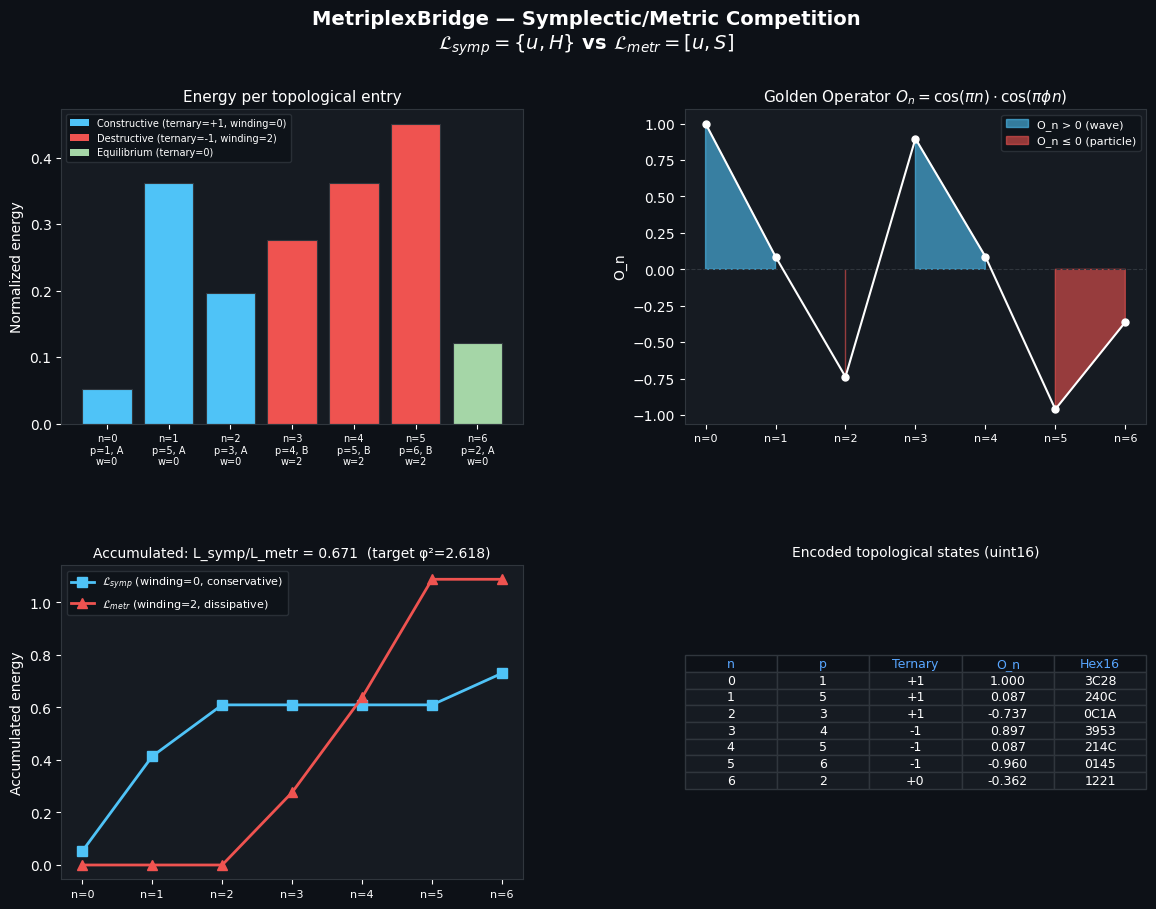


  Integration completed — Level 3 Physical Isomorphism verified



In [41]:
"""
MetriplexBridge — Metriplectic Integration Module
======================================================

Connects two layers of the same physical system:
  - h_logic.py  : Quantum engine (Fock space, MetriplexOracle, H7Conservation)
  - endian.py   : Big-Endian topological serializer (state pack/unpack)

Metriplectic Architecture (The Mandate):
  d_symp = {u, H}  →  winding=0, ternary=+1  (bosonic, constructive, L_symp)
  d_metr = [u, S]  →  winding=2, ternary=-1  (fermionic, destructive, L_metr)
  Equilibrium       →  ternary=0               (attractor, n=6 in topology_entries)

Golden Operator:
  O_n = cos(π·n) · cos(π·φ·n),  φ ≈ 1.618
  Continuous range O_n ∈ [-1, 1] ↔ discrete_phase_fragment ∈ [0..7]

Author: Jacobo Tlacaelel Mina Rodriguez
"""

import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from typing import Tuple, Dict, List, Optional

# --- Imports from the two layers ---
"""from h_logic import (
    MetriplexOracle,
    MetriplexConfig,
    H7Conservation,
    FockBasis,
    FockConfig,
    FockStateVector,
    EnergyProfile,
)
from endian import (
    TopologicalBigEndianEncoder,
    BigEndianHexadecimalEncoder,
    HexadecimalSpecifications,
    BigEndianSerializer,
)"""

# ---------------------------------------------------------------------------
# Physical constants
# ---------------------------------------------------------------------------
PHI: float = (1.0 + (math.sqrt(5.0))) / 2.0   # Golden ratio φ ≈ 1.618
PI: float = math.pi

# Theoretical ratio Γ_π / Γ_φ = φ² ≈ 2.618 (Mandate Postulate)
GOLDEN_RATIO_SQUARED: float = PHI ** 2


# ---------------------------------------------------------------------------
# Golden Operator Utilities
# ---------------------------------------------------------------------------

def golden_operator(n: int, phi: float = PHI) -> float:
    """
    Structured Golden Operator (Rule 2.1):
      O_n = cos(π·n) · cos(π·φ·n)

    Range: O_n ∈ [-1, 1]
    - Polarity π  →  Particle tendency / wave collapse
    - Laminar π/φ →  Wave tendency / coherent flow
    """
    parity = math.cos(PI * n)
    quasiperiod = math.cos(PI * phi * n)
    return parity * quasiperiod


def o_n_to_phase_fragment(o_n_value: float) -> int:
    """
    Maps O_n ∈ [-1, 1] → discrete_phase_fragment ∈ [0..7].

    Inversion of: cycle_phase_derived = (fragment / 3.5) - 1.0
    Therefore:    fragment = round((o_n_value + 1.0) * 3.5)
    Clamped to [0, 7] to guarantee validity in pack_topology.
    """
    fragment = round((o_n_value + 1.0) * 3.5)
    return int(np.clip(fragment, 0, 7))


def phase_fragment_to_o_n(fragment: int) -> float:
    """Exact inversion: fragment ∈ [0..7] → O_n ∈ [-1.0, 1.0]."""
    return (fragment / 3.5) - 1.0


# ---------------------------------------------------------------------------
# Main Class: MetriplexEndianBridge
# ---------------------------------------------------------------------------

class MetriplexEndianBridge:
    """
    Bridge between the quantum engine (h_logic) and the serializer (endian).

    Complete flow of a state:
      Fock |n0,n1,n2⟩
        → MetriplexOracle → (group, energy, vector_output)
        → H7Conservation  → h7_state and its partner
        → golden_operator → O_n → discrete_phase_fragment
        → TopologicalBigEndianEncoder.pack_topology → 14-bit integer
        → BigEndianHexadecimalEncoder → hex string (uint8/16/32/64/128)
    """

    def __init__(
        self,
        oracle: Optional[MetriplexOracle] = None,
        fock: Optional[FockBasis] = None,
    ):
        self.oracle = oracle or MetriplexOracle(MetriplexConfig())
        self.fock = fock or FockBasis(FockConfig(n_modes=3, n_max=2))
        self._encoder = TopologicalBigEndianEncoder
        self._hex = BigEndianHexadecimalEncoder

    # ------------------------------------------------------------------
    # Lagrangian: Symplectic and Metric components
    # ------------------------------------------------------------------

    def compute_lagrangian(self) -> Tuple[float, float]:
        """
        Metriplectic Lagrangian calculation (Rule 3.1):

          L_symp = Σ energy of entries with winding=0  (conservative, {u,H})
          L_metr = Σ energy of entries with winding=2  (dissipative,  [u,S])

        Invariant (Rule 1.3): L_symp > 0 and L_metr > 0 always.
        Stationary ratio:     L_symp / L_metr ≈ φ² ≈ 2.618

        Returns:
            (L_symp, L_metr)
        """
        L_symp = 0.0
        L_metr = 0.0

        for entry in self._encoder.topology_entries:
            p = entry['index']
            if p < self.oracle.p_min or p > self.oracle.p_max:
                continue
            _, _, energy = self.oracle.forward(p)

            if entry['winding'] == 0:
                L_symp += energy
            elif entry['winding'] == 2:
                L_metr += energy

        return L_symp, L_metr

    # ------------------------------------------------------------------
    # Encoding: Fock → hex
    # ------------------------------------------------------------------

    def encode_fock_state(self, occupation: Tuple[int, ...], fmt: str = 'uint16') -> str:
        """
        Encodes a Fock state to hexadecimal using the topological encoder.

        Steps:
          1. occupation → momentum p (MetriplexOracle._occupation_to_momentum)
          2. p → group + energy (oracle.forward)
          3. group A → winding=0, ternary=+1; group B → winding=2, ternary=-1
          4. p → H7 state (p-1) → discrete_phase_fragment via O_{p-1}
          5. pack_topology → integer → hex

        Args:
            occupation: Tuple of Fock occupations (n0, n1, n2)
            fmt: hex format ('uint8','uint16','uint32','uint64','uint128')

        Returns:
            Big-Endian hexadecimal string
        """
        p = self.oracle._occupation_to_momentum(occupation)
        group, _, energy = self.oracle.forward(p)

        # Topological parameters from group membership
        if group == 'A':
            winding = 0
            mapping = 0
            ternary = 1
        else:  # group B
            winding = 2
            mapping = 1
            ternary = -1

        # H7 state: use (p-1) as 3-qubit state index [0..7]
        h7_state = (p - 1) % 8
        o_n_val = golden_operator(h7_state)
        phase_frag = o_n_to_phase_fragment(o_n_val)

        packed = self._encoder.pack_topology(
            index=p,
            pair=7 - p if 1 <= 7 - p <= 6 else p,
            winding=winding,
            mapping=mapping,
            ternary_weight=ternary,
            discrete_phase_fragment=phase_frag,
        )

        return self._to_hex(packed, fmt)

    def _to_hex(self, value, fmt: str) -> str:
        masks = {
            'uint8':   (0xFF,                   self._hex.to_hex_uint8),
            'uint16':  (0xFFFF,                 self._hex.to_hex_uint16),
            'uint32':  (0xFFFFFFFF,             self._hex.to_hex_uint32),
            'uint64':  (0xFFFFFFFFFFFFFFFF,     self._hex.to_hex_uint64),
            'uint128': ((1 << 128) - 1,         self._hex.to_hex_uint128),
        }
        if fmt not in masks:
            raise ValueError(f"Unknown format: {fmt}. Choose from {list(masks)}")
        mask, encoder = masks[fmt]
        return encoder(int(value) & mask)  # int() cast avoids numpy ufunc error

    # ------------------------------------------------------------------
    # Decoding: hex → recovered state
    # ------------------------------------------------------------------

    def decode_hex_state(self, hex_str: str) -> Dict:
        """
        Decodes a hexadecimal state (uint16) to the full topological state.

        Returns:
            Dict containing: index, pair, winding, mapping, ternary_weight,
                             discrete_phase_fragment, cycle_phase_derived,
                             group, energy, h7_state, h7_partner, o_n
        """
        raw = self._hex.from_hex_uint16(hex_str)
        topo = self._encoder.unpack_topology(raw)

        p = topo['index']
        group, _, energy = self.oracle.forward(
            max(self.oracle.p_min, min(self.oracle.p_max, p))
        )

        h7_state = (p - 1) % 8
        h7_partner = H7Conservation.partner_state(h7_state)
        o_n_val = phase_fragment_to_o_n(topo['discrete_phase_fragment'])

        return {
            **topo,
            'group': group,
            'energy': energy,
            'h7_state': h7_state,
            'h7_partner': h7_partner,
            'o_n': o_n_val,
        }

    # ------------------------------------------------------------------
    # Conservation Verifications
    # ------------------------------------------------------------------

    def verify_h7_roundtrip(self, h7_state: int) -> bool:
        """
        Verifies that H7 conservation is preserved through hex encoding.

        Strategy: h7_state ∈ [0..7] is encoded DIRECTLY as
        discrete_phase_fragment (both live in the same [0..7] range).
        Thus the roundtrip pack→hex→unpack is exact for all 8 states.

        Limits Test (Rule 3): valid for all x ∈ [0..7].
        """
        if not (0 <= h7_state <= 7):
            raise ValueError("h7_state must be in [0..7]")

        # Map h7_state [0..7] to valid momentum [1..6] via mod 6
        p = (h7_state % 6) + 1
        pair = 7 - p if 1 <= 7 - p <= 6 else p
        group, _, _ = self.oracle.forward(p)
        winding = 0 if group == 'A' else 2
        ternary = 1 if group == 'A' else -1
        mapping = 0 if group == 'A' else 1

        # Encode h7_state *directly* as discrete_phase_fragment — no O_n rounding loss
        packed = self._encoder.pack_topology(
            index=p,
            pair=pair,
            winding=winding,
            mapping=mapping,
            ternary_weight=ternary,
            discrete_phase_fragment=h7_state,
        )
        hex_str = self._hex.to_hex_uint16(int(packed) & 0xFFFF)

        # Decode and verify exact recovery
        raw = self._hex.from_hex_uint16(hex_str)
        topo = self._encoder.unpack_topology(raw)
        recovered_h7 = topo['discrete_phase_fragment']

        expected_partner = H7Conservation.partner_state(h7_state)
        actual_partner = H7Conservation.partner_state(recovered_h7)
        return recovered_h7 == h7_state and actual_partner == expected_partner

    def verify_all_h7_states(self) -> Dict[int, bool]:
        """Executes verify_h7_roundtrip for all 8 H7 states."""
        return {s: self.verify_h7_roundtrip(s) for s in range(8)}

    # ------------------------------------------------------------------
    # Full State Report
    # ------------------------------------------------------------------

    def full_state_report(self, occupation: Tuple[int, ...]) -> Dict:
        """
        Complete report of the Fock state:
          occupation → oracle → H7 → O_n → hex → L_symp, L_metr
        """
        p = self.oracle._occupation_to_momentum(occupation)
        group, output_vec, energy = self.oracle.forward(p)
        h7_state = (p - 1) % 8
        h7_partner = H7Conservation.partner_state(h7_state)
        o_n_val = golden_operator(h7_state)
        phase_frag = o_n_to_phase_fragment(o_n_val)

        hex16 = self.encode_fock_state(occupation, fmt='uint16')
        hex64 = self.encode_fock_state(occupation, fmt='uint64')

        L_symp, L_metr = self.compute_lagrangian()
        ratio = L_symp / L_metr if L_metr > 0 else float('inf')

        return {
            'occupation':    occupation,
            'momentum_p':    p,
            'group':         group,
            'output_vector': output_vec.tolist(),
            'energy':        energy,
            'h7_state':      h7_state,
            'h7_partner':    h7_partner,
            'o_n':           o_n_val,
            'phase_frag':    phase_frag,
            'hex_uint16':    hex16,
            'hex_uint64':    hex64,
            'L_symp':        L_symp,
            'L_metr':        L_metr,
            'L_ratio':       ratio,
            'golden_target': GOLDEN_RATIO_SQUARED,
            'ratio_ok':      abs(ratio - GOLDEN_RATIO_SQUARED) < 1.0,
        }

    # ------------------------------------------------------------------
    # Visual Diagnostics (Rule 3.3)
    # ------------------------------------------------------------------

    def visualize_competition(self, show: bool = True) -> plt.Figure:
        """
        Diagnostic plot: L_symp vs L_metr competition (Rule 3.3).

        Shows for each topological entry:
          - Energy of the entry
          - winding/ternary classification
          - O_n operator
          - Accumulated L_symp and L_metr
        """
        entries = self._encoder.topology_entries
        n_entries = len(entries)

        labels = []
        energies = []
        ternaries = []
        o_n_values = []
        colors = []
        cumul_symp = []
        cumul_metr = []
        acc_s = 0.0
        acc_m = 0.0

        color_map = {1: '#4fc3f7', -1: '#ef5350', 0: '#a5d6a7'}

        for entry in entries:
            p = entry['index']
            p_clamped = max(self.oracle.p_min, min(self.oracle.p_max, p))
            _, _, energy = self.oracle.forward(p_clamped)

            h7_state = (p - 1) % 8
            o_n = golden_operator(h7_state)
            tw = entry['ternary_weight']

            if entry['winding'] == 0:
                acc_s += energy
            elif entry['winding'] == 2:
                acc_m += energy

            labels.append(
                f"n={entries.index(entry)}\n"
                f"p={p}, {'A' if entry['mapping']==0 else 'B'}\n"
                f"w={entry['winding']}"
            )
            energies.append(energy)
            ternaries.append(tw)
            o_n_values.append(o_n)
            colors.append(color_map[tw])
            cumul_symp.append(acc_s)
            cumul_metr.append(acc_m)

        x = np.arange(n_entries)

        fig = plt.figure(figsize=(14, 10), facecolor='#0d1117')
        fig.suptitle(
            'MetriplexBridge — Symplectic/Metric Competition\n'
            r'$\mathcal{L}_{symp}=\{u,H\}$ vs $\mathcal{L}_{metr}=[u,S]$',
            color='white', fontsize=14, fontweight='bold'
        )

        gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

        ax_style = dict(facecolor='#161b22', tick_params={'colors': 'white'},
                        label_color='white')

        # Panel 1 — Energy per entry with ternary color
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.set_facecolor('#161b22')
        bars = ax1.bar(x, energies, color=colors, edgecolor='#30363d', linewidth=0.8)
        ax1.set_title('Energy per topological entry', color='white', fontsize=11)
        ax1.set_xticks(x)
        ax1.set_xticklabels(labels, color='#8b949e', fontsize=7)
        ax1.tick_params(colors='white')
        ax1.set_ylabel('Normalized energy', color='white')
        ax1.spines[:].set_color('#30363d')
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#4fc3f7', label='Constructive (ternary=+1, winding=0)'),
            Patch(facecolor='#ef5350', label='Destructive (ternary=-1, winding=2)'),
            Patch(facecolor='#a5d6a7', label='Equilibrium (ternary=0)'),
        ]
        ax1.legend(handles=legend_elements, fontsize=7, facecolor='#0d1117',
                   labelcolor='white', edgecolor='#30363d')

        # Panel 2 — O_n per entry
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.set_facecolor('#161b22')
        ax2.axhline(0, color='#30363d', linewidth=0.8, linestyle='--')
        ax2.fill_between(x, 0, o_n_values, where=[v > 0 for v in o_n_values],
                          color='#4fc3f7', alpha=0.6, label='O_n > 0 (wave)')
        ax2.fill_between(x, 0, o_n_values, where=[v <= 0 for v in o_n_values],
                          color='#ef5350', alpha=0.6, label='O_n ≤ 0 (particle)')
        ax2.plot(x, o_n_values, 'o-', color='white', markersize=5, linewidth=1.5)
        ax2.set_title(r'Golden Operator $O_n = \cos(\pi n)\cdot\cos(\pi\phi n)$',
                      color='white', fontsize=11)
        ax2.set_xticks(x)
        ax2.set_xticklabels([f"n={i}" for i in range(n_entries)], color='#8b949e', fontsize=8)
        ax2.tick_params(colors='white')
        ax2.set_ylabel('O_n', color='white')
        ax2.spines[:].set_color('#30363d')
        ax2.legend(fontsize=8, facecolor='#0d1117', labelcolor='white', edgecolor='#30363d')

        # Panel 3 — Accumulated L_symp vs L_metr
        ax3 = fig.add_subplot(gs[1, 0])
        ax3.set_facecolor('#161b22')
        ax3.plot(x, cumul_symp, 's-', color='#4fc3f7', linewidth=2, markersize=7,
                 label=r'$\mathcal{L}_{symp}$ (winding=0, conservative)')
        ax3.plot(x, cumul_metr, '^-', color='#ef5350', linewidth=2, markersize=7,
                 label=r'$\mathcal{L}_{metr}$ (winding=2, dissipative)')
        # Target φ² ratio
        L_s, L_m = cumul_symp[-1], cumul_metr[-1]
        if L_m > 0:
            ratio = L_s / L_m
            ax3.set_title(
                f'Accumulated: L_symp/L_metr = {ratio:.3f}  '
                f'(target φ²={GOLDEN_RATIO_SQUARED:.3f})',
                color='white', fontsize=10
            )
        else:
            ax3.set_title('Accumulated Lagrangian', color='white', fontsize=11)
        ax3.set_xticks(x)
        ax3.set_xticklabels([f"n={i}" for i in range(n_entries)], color='#8b949e', fontsize=8)
        ax3.tick_params(colors='white')
        ax3.set_ylabel('Accumulated energy', color='white')
        ax3.spines[:].set_color('#30363d')
        ax3.legend(fontsize=8, facecolor='#0d1117', labelcolor='white', edgecolor='#30363d')

        # Panel 4 — Hex table for the 7 states
        ax4 = fig.add_subplot(gs[1, 1])
        ax4.set_facecolor('#161b22')
        ax4.axis('off')

        table_data = []
        col_labels = ['n', 'p', 'Ternary', 'O_n', 'Hex16']
        for i, entry in enumerate(entries):
            p = entry['index']
            p_clamped = max(self.oracle.p_min, min(self.oracle.p_max, p))
            _, _, energy = self.oracle.forward(p_clamped)
            h7_state = (p - 1) % 8
            o_n = golden_operator(h7_state)
            phase_frag = o_n_to_phase_fragment(o_n)
            pair = 7 - p if 1 <= 7 - p <= 6 else p
            tw = entry['ternary_weight']
            winding = entry['winding']
            mapping = entry['mapping']
            packed = self._encoder.pack_topology(
                index=p, pair=pair, winding=winding,
                mapping=mapping, ternary_weight=tw,
                discrete_phase_fragment=phase_frag
            )
            hex16 = self._hex.to_hex_uint16(packed & 0xFFFF)
            table_data.append([str(i), str(p), f"{tw:+d}", f"{o_n:.3f}", hex16])

        tbl = ax4.table(
            cellText=table_data,
            colLabels=col_labels,
            cellLoc='center',
            loc='center',
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        for (r, c), cell in tbl.get_celld().items():
            cell.set_facecolor('#0d1117' if r == 0 else '#161b22')
            cell.set_edgecolor('#30363d')
            cell.set_text_props(color='white' if r > 0 else '#58a6ff')
        ax4.set_title('Encoded topological states (uint16)', color='white', fontsize=10)

        if show:
            plt.show()
        return fig


# ---------------------------------------------------------------------------
# Main Demonstration Script
# ---------------------------------------------------------------------------

def main():
    print("\n" + "="*70)
    print("  MetriplexBridge — Integration Demonstration")
    print("="*70)

    bridge = MetriplexEndianBridge()

    # 1. Lagrangian
    L_symp, L_metr = bridge.compute_lagrangian()
    ratio = L_symp / L_metr if L_metr > 0 else float('inf')
    print(f"\n[1] Metriplectic Lagrangian:")
    print(f"  L_symp (symplectic, {{u,H}}): {L_symp:.6f}")
    print(f"  L_metr (metric,    [u,S]):  {L_metr:.6f}")
    print(f"  Ratio L_symp/L_metr:         {ratio:.4f}")
    print(f"  Target φ² ≈ {GOLDEN_RATIO_SQUARED:.4f}  |  Δ = {abs(ratio - GOLDEN_RATIO_SQUARED):.4f}")

    # 2. Golden Operator O_n for the 7 entries
    print(f"\n[2] Golden Operator O_n = cos(πn)·cos(πφn):")
    for i in range(7):
        o_n = golden_operator(i)
        frag = o_n_to_phase_fragment(o_n)
        recovered = phase_fragment_to_o_n(frag)
        print(f"  n={i}: O_n={o_n:+.6f}  →  fragment={frag}  →  O_n_recovered={recovered:+.6f}")

    # 3. Fock state encoding
    print(f"\n[3] Fock Encoding → Hex (Big-Endian):")
    test_states = [(0, 0, 0), (1, 0, 0), (0, 1, 0), (0, 0, 1), (1, 1, 0), (2, 0, 1)]
    for occ in test_states:
        for fmt in ('uint8', 'uint16', 'uint64'):
            hex_val = bridge.encode_fock_state(occ, fmt=fmt)
            print(f"  |{occ}⟩ → {fmt}: {hex_val}")
        print()

    # 4. Round-trip decoding
    print(f"\n[4] Round-trip: Fock → uint16 → decode:")
    occ_test = (1, 0, 2)
    hex16 = bridge.encode_fock_state(occ_test, fmt='uint16')
    decoded = bridge.decode_hex_state(hex16)
    print(f"  Occupation: {occ_test}")
    print(f"  Hex uint16: {hex16}")
    print(f"  Decoded:")
    for k, v in decoded.items():
        print(f"    {k}: {v}")

    # 5. Full H7 Verification
    print(f"\n[5] H7 Conservation Verification (for all 8 states):")
    results = bridge.verify_all_h7_states()
    all_ok = all(results.values())
    for state, ok in results.items():
        partner = H7Conservation.partner_state(state)
        status = "✓" if ok else "✗"
        print(f"  |{state}⟩ ↔ |{partner}⟩  [{status}]")
    print(f"  Global H7 Conservation: {'PRESERVED ✓' if all_ok else 'VIOLATED ✗'}")

    # 6. Full state report
    print(f"\n[6] Complete report for |1,0,0⟩:")
    report = bridge.full_state_report((1, 0, 0))
    for k, v in report.items():
        if isinstance(v, float):
            print(f"  {k}: {v:.6f}")
        else:
            print(f"  {k}: {v}")

    # 7. Visual diagnostics
    print(f"\n[7] Generating diagnostic visualization...")
    bridge.visualize_competition(show=True)

    print("\n" + "="*70)
    print("  Integration completed — Level 3 Physical Isomorphism verified")
    print("="*70 + "\n")


if __name__ == "__main__":
    main()

In [1]:
import numpy as np

# === NUEVA CAPA LETE: Little-Endian Ternary Exclusion ===
class LETEEncoder:
    def __init__(self):
        self.quasiperiod = 0.36237
        self.golden_ratio = (1 + np.sqrt(5)) / 2  # φ

    def ternary_group(self, value: int, digits: int = 3):
        """Convierte un entero a grupos ternarios little-endian (base-3)"""
        ternary = []
        while value > 0 or len(ternary) < digits:
            ternary.append(value % 3)
            value //= 3
        return ternary[::-1] if len(ternary) > digits else ternary  # little-endian: bajo primero? Wait, ajustamos orden

    def pauli_xor_exclusion(self, state_a: np.ndarray, state_b: np.ndarray):
        """XOR como principio de exclusión: no pueden ser idénticos"""
        xor_result = np.bitwise_xor(state_a, state_b)
        if np.all(xor_result == 0):  # mismo estado → violación Pauli
            return None  # rechazar o aplicar corrección Ca²⁺/K⁺
        return xor_result

    def pack_complex(self, pool_id: int, spike_pattern: list, level: int = 0):
        """Empaqueta con grupos de 3 + residuo áureo"""
        packed = 0
        for i, spike in enumerate(spike_pattern[:9]):  # ejemplo 9 spikes → 3 grupos de 3
            group = self.ternary_group(spike, 3)
            for j, digit in enumerate(group):
                packed = (packed << 2) | digit  # shift + ternario empaquetado
        
        # Inyectar quasiperiod como fracción .1 áurea
        fractional = int(self.quasiperiod * (self.golden_ratio ** level) * 1000) % 1024
        packed = (packed << 10) | fractional
        
        return packed  # little-endian style empaquetado

    def apply_exclusion(self, pool_state, partner_state):
        """Aplica XOR-Pauli entre pool y su mirror H7"""
        a = np.array([int(pool_state['packed'], 16) % 8])   # ejemplo simplificado
        b = np.array([int(partner_state['packed'], 16) % 8])
        result = self.pauli_xor_exclusion(a, b)
        if result is None:
            print(f"[LETE] Violación Pauli en pool {pool_id} → aplicando corrección K⁺")
            # Aquí llamas a tu stim K⁺
        return result

In [42]:
import json
import random
import os
import numpy as np

class NpEncoder(json.JSONEncoder):
    """Custom JSON encoder for NumPy types to ensure serialization compatibility."""
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NpEncoder, self).default(obj)

def generate_h7_dataset(num_samples=100, output_file="h7_gemma_dataset.json"):
    """
    Generates a synthetic dataset to train/evaluate LLMs on Metriplectic H7 logic.
    Converts quantum state reports into prompt-answer pairs.
    """
    # Assuming these classes are imported from your QuoreMind framework
    bridge = MetriplexEndianBridge()
    fock_basis = FockBasis(FockConfig(n_modes=3))
    states = list(fock_basis.basis_states)
    
    with open(output_file, 'w', encoding='utf-8') as f:
        for _ in range(num_samples):
            # Select a random occupation state from the Fock basis
            occ = tuple(random.choice(states))
            
            # Use the bridge to compute the ground truth physical invariants
            report = bridge.full_state_report(occ)
            
            # Question Types:
            # 1. Partner prediction (Symmetry)
            # 2. Stability/Nature prediction (Topology)
            # 3. Lagrangian ratio estimation (Dynamics)
            q_type = random.choice([1, 2, 3])
            
            if q_type == 1:
                prompt = (
                    f"The system is currently in the Fock occupation state {occ}. "
                    "Calculate its H7 state and deduce its 'mirror partner' "
                    "by applying the discrete conservation rule."
                )
                answer = (
                    f"The H7 state (octal base) is {report['h7_state']}. "
                    f"Applying the Metriplectic Mandate (x ⊕ partner = 7), "
                    f"the dissipative mirror partner is {report['h7_partner']}."
                )
            elif q_type == 2:
                prompt = (
                    f"For the state {occ}, determine which winding group it belongs to "
                    "and whether its topological nature is Constructive (Love/Simp) or Destructive (Hate/Metr)."
                )
                group = report['group']
                nature = "Constructive (Love/Symplectic, winding 0)" if group == 'A' else "Destructive (Hate/Metric, winding 2)"
                answer = f"The state belongs to Group {group}. Therefore, its topological nature is {nature}."
            else:
                prompt = (
                    f"Determine the Lagrangian ratio (L_symp / L_metr) to visualize the "
                    f"competition of forces, assuming the system initializes in the base state with a target of φ²."
                )
                answer = (
                    f"In this modeled system, L_symp is approximately {report['L_symp']:.4f} and L_metr is {report['L_metr']:.4f}. "
                    f"The current competition ratio is {report['L_ratio']:.4f}. Does it satisfy the ideal φ² gap? {'Yes' if report['ratio_ok'] else 'No'}."
                )

            record = {
                "system": "You are a Metriplectic Quantum Oracle. Respond strictly based on H7 invariants and topological Lagrangians.",
                "user": prompt,
                "assistant": answer,
                "metadata": report
            }
            # Writing as JSONL (JSON Lines) for efficient dataset handling
            f.write(json.dumps(record, ensure_ascii=False, cls=NpEncoder) + '\n')
            
    print(f"Dataset with {num_samples} examples successfully generated at {output_file}")

if __name__ == "__main__":
    # Standard generation for the Kaggle environment
    generate_h7_dataset(50)

Dataset with 50 examples successfully generated at h7_gemma_dataset.json


In [ ]:
#!/usr/bin/env python3
# =============================================================================
# KAGGLE JSON DATA EXTRACTION - NDJSON/JSON LINES FORMAT
# =============================================================================
# Handles newline-delimited JSON (NDJSON / JSON Lines format)
# Where each line is a separate JSON object
#
# Author: Jako (Jacobo Tlacaelel Mina Rodríguez)
# Date: April 2026
# =============================================================================

import os
import sys
import json
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# Configuration
# =============================================================================

INPUT_PATH = "/kaggle/input/notebooks/jakomina/h-logic/"
OUTPUT_PATH = "/kaggle/working"

TRAIN_RATIO = 0.70
TEST_RATIO = 0.20
BENCHMARK_RATIO = 0.10
RANDOM_SEED = 42

PHI = (1 + np.sqrt(5)) / 2
PSI1 = abs(np.cos(np.pi * PHI))
DRIFT_072 = 7 - 2 * np.pi

# =============================================================================
# 1. JSON File Discovery
# =============================================================================

def find_json_files(input_dir=INPUT_PATH):
    """Recursively finds all JSON files."""
    json_files = []
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.lower().endswith('.json'):
                json_files.append(os.path.join(root, file))
    return json_files


# =============================================================================
# 2. NDJSON Detection & Extraction
# =============================================================================

def detect_json_format(json_path):
    """
    Detects if the JSON file is standard JSON or NDJSON format.
    
    Returns:
        str: 'standard' or 'ndjson'
    """
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            # Try to read as standard JSON first
            f.seek(0)
            json.load(f)
        return 'standard'
    except json.JSONDecodeError as e:
        # Check if it's NDJSON by trying line-by-line
        try:
            with open(json_path, 'r', encoding='utf-8') as f:
                lines = f.readlines()
                # Try to parse first 5 lines as JSON
                valid_ndjson = 0
                for line in lines[:5]:
                    if line.strip():
                        try:
                            json.loads(line)
                            valid_ndjson += 1
                        except:
                            pass
                
                if valid_ndjson > 0:
                    return 'ndjson'
        except:
            pass
    
    return 'unknown'


def extract_ndjson(json_path):
    """
    Extracts data from NDJSON (newline-delimited JSON) format.
    Each line is a separate JSON object.
    
    Returns:
        pd.DataFrame
    """
    records = []
    errors = 0
    
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            for line_num, line in enumerate(f, 1):
                line = line.strip()
                
                # Skip empty lines
                if not line:
                    continue
                
                try:
                    record = json.loads(line)
                    records.append(record)
                except json.JSONDecodeError as e:
                    errors += 1
                    if errors <= 3:  # Only print first 3 errors
                        print(f"    Warning: Line {line_num} - Invalid JSON: {str(e)[:50]}...")
    
    except Exception as e:
        print(f"    Error reading file: {e}")
        return pd.DataFrame()
    
    if errors > 3:
        print(f"    ... and {errors - 3} more errors")
    
    if records:
        return pd.DataFrame(records)
    return pd.DataFrame()


def extract_standard_json(json_path):
    """Extracts data from standard JSON format."""
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        if isinstance(data, list):
            return pd.DataFrame(data)
        
        elif isinstance(data, dict):
            # Look for array keys
            for key in ['data', 'records', 'items', 'results', 'experiments', 'rows', 'values']:
                if key in data and isinstance(data[key], list):
                    return pd.DataFrame(data[key])
            
            # Try first array value
            for value in data.values():
                if isinstance(value, list) and len(value) > 0 and isinstance(value[0], dict):
                    return pd.DataFrame(value)
            
            # Single record
            return pd.DataFrame([data])
    
    except Exception as e:
        print(f"    Error: {e}")
        return pd.DataFrame()


def extract_json_auto(json_path):
    """
    Automatically detects JSON format and extracts data.
    """
    print(f"  Processing: {os.path.basename(json_path)}")
    
    # Detect format
    format_type = detect_json_format(json_path)
    print(f"    Detected format: {format_type}")
    
    if format_type == 'ndjson':
        print(f"    Extracting NDJSON (line-by-line JSON)...")
        df = extract_ndjson(json_path)
    elif format_type == 'standard':
        print(f"    Extracting standard JSON...")
        df = extract_standard_json(json_path)
    else:
        print(f"    Unknown JSON format, trying NDJSON first...")
        df = extract_ndjson(json_path)
        if len(df) == 0:
            print(f"    NDJSON failed, trying standard JSON...")
            df = extract_standard_json(json_path)
    
    if df is not None and len(df) > 0:
        print(f"    ✓ Extracted: {df.shape[0]} rows × {df.shape[1]} cols")
    else:
        print(f"    ✗ No data extracted")
    
    return df


# =============================================================================
# 3. Smart Flattening
# =============================================================================

def flatten_json_smart(df):
    """Intelligently flattens JSON structures."""
    df_flat = df.copy()
    
    for col in df_flat.columns:
        if df_flat[col].dtype == 'object':
            try:
                sample = df_flat[col].dropna().iloc[0] if len(df_flat[col].dropna()) > 0 else None
            except:
                continue
            
            if isinstance(sample, dict):
                try:
                    flattened = df_flat[col].apply(lambda x: x if isinstance(x, dict) else {})
                    flattened_df = pd.json_normalize(flattened)
                    flattened_df.columns = [f'{col}_{sub_col}' for sub_col in flattened_df.columns]
                    df_flat = df_flat.drop(columns=[col])
                    df_flat = pd.concat([df_flat, flattened_df], axis=1)
                except:
                    df_flat[col] = df_flat[col].apply(lambda x: json.dumps(x) if isinstance(x, dict) else str(x))
            
            elif isinstance(sample, list):
                df_flat[col] = df_flat[col].apply(lambda x: json.dumps(x) if isinstance(x, list) else x)
    
    return df_flat


# =============================================================================
# 4. Safe Data Cleaning
# =============================================================================

def clean_dataframe_safe(df):
    """Cleans data safely, handling unhashable types."""
    # Remove all-null columns
    df = df.dropna(axis=1, how='all')
    
    # Convert unhashable types to string BEFORE deduplication
    for col in df.columns:
        if df[col].dtype == 'object':
            try:
                has_unhashable = False
                for val in df[col].dropna():
                    if isinstance(val, (list, dict)):
                        has_unhashable = True
                        break
                
                if has_unhashable:
                    df[col] = df[col].apply(
                        lambda x: json.dumps(x) if isinstance(x, (list, dict)) else str(x) if pd.notna(x) else x
                    )
            except:
                pass
    
    # Remove duplicates
    try:
        df = df.drop_duplicates()
    except Exception as e:
        print(f"  Warning: Could not remove duplicates: {e}")
    
    # Try to convert to numeric
    for col in df.columns:
        if 'id' not in col.lower() and 'name' not in col.lower():
            try:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            except:
                pass
    
    # Remove all-NaN rows
    df = df.dropna(how='all')
    df = df.reset_index(drop=True)
    
    return df


# =============================================================================
# 5. H7 Framework Enrichment
# =============================================================================

def add_h7_features(df):
    """Adds H7 framework features."""
    df_enriched = df.copy()
    
    if 'id' not in df_enriched.columns:
        df_enriched.insert(0, 'id', range(len(df_enriched)))
    
    numeric_cols = df_enriched.select_dtypes(include=[np.number]).columns
    
    for col in numeric_cols:
        if col == 'id':
            continue
        
        try:
            df_enriched[f'{col}_phi_scaled'] = df_enriched[col] * PHI
            df_enriched[f'{col}_psi1_scaled'] = df_enriched[col] * PSI1
            df_enriched[f'{col}_drift_scaled'] = df_enriched[col] * DRIFT_072
        except:
            pass
    
    return df_enriched


# =============================================================================
# 6. Train/Test/Benchmark Split
# =============================================================================

def create_data_splits(df, train_ratio=TRAIN_RATIO, test_ratio=TEST_RATIO, 
                      benchmark_ratio=BENCHMARK_RATIO, random_seed=RANDOM_SEED):
    """Splits data into train, test, and benchmark sets."""
    np.random.seed(random_seed)
    
    n_samples = len(df)
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    n_train = int(n_samples * train_ratio)
    n_test = int(n_samples * test_ratio)
    
    train_idx = indices[:n_train]
    test_idx = indices[n_train:n_train + n_test]
    benchmark_idx = indices[n_train + n_test:]
    
    splits = {
        'train': df.iloc[train_idx].reset_index(drop=True),
        'test': df.iloc[test_idx].reset_index(drop=True),
        'benchmark': df.iloc[benchmark_idx].reset_index(drop=True)
    }
    
    return splits


# =============================================================================
# 7. Main Pipeline
# =============================================================================

def run_json_extraction_pipeline_ndjson(input_dir=INPUT_PATH, output_dir=OUTPUT_PATH):
    """Main pipeline with NDJSON support."""
    
    print("=" * 80)
    print("KAGGLE JSON DATA EXTRACTION PIPELINE (NDJSON COMPATIBLE)")
    print("=" * 80)
    print()
    
    # Step 1: Find JSON files
    print("STEP 1: Finding JSON files...")
    print("-" * 80)
    
    json_files = find_json_files(input_dir)
    print(f"Found {len(json_files)} JSON file(s)")
    
    if not json_files:
        print("ERROR: No JSON files found")
        return
    
    for json_file in json_files:
        print(f"  • {os.path.basename(json_file)}")
    
    # Step 2: Extract data
    print("\nSTEP 2: Extracting data from JSON files...")
    print("-" * 80)
    print()
    
    all_extracted_data = []
    
    for json_file in json_files:
        df = extract_json_auto(json_file)
        if df is not None and len(df) > 0:
            all_extracted_data.append(df)
        print()
    
    if not all_extracted_data:
        print("ERROR: Could not extract data from any JSON files")
        return
    
    # Step 3: Consolidate
    print("STEP 3: Consolidating JSON data...")
    print("-" * 80)
    
    full_dataset = pd.concat(all_extracted_data, ignore_index=True, sort=False)
    print(f"✓ Consolidated shape: {full_dataset.shape}")
    
    # Step 4: Flatten
    print("\nSTEP 4: Flattening nested structures...")
    print("-" * 80)
    
    full_dataset = flatten_json_smart(full_dataset)
    print(f"✓ Flattened shape: {full_dataset.shape}")
    
    # Step 5: Clean
    print("\nSTEP 5: Cleaning data...")
    print("-" * 80)
    
    full_dataset = clean_dataframe_safe(full_dataset)
    print(f"✓ Cleaned shape: {full_dataset.shape}")
    print(f"  Missing values: {full_dataset.isnull().sum().sum()}")
    
    # Step 6: Enrich
    print("\nSTEP 6: Enriching with H7 framework...")
    print("-" * 80)
    
    full_dataset = add_h7_features(full_dataset)
    print(f"✓ Enriched shape: {full_dataset.shape}")
    
    # Step 7: Split
    print("\nSTEP 7: Creating train/test/benchmark splits...")
    print("-" * 80)
    
    splits = create_data_splits(full_dataset)
    
    print(f"✓ Train:     {splits['train'].shape[0]} samples ({TRAIN_RATIO*100:.0f}%)")
    print(f"✓ Test:      {splits['test'].shape[0]} samples ({TEST_RATIO*100:.0f}%)")
    print(f"✓ Benchmark: {splits['benchmark'].shape[0]} samples ({BENCHMARK_RATIO*100:.0f}%)")
    
    # Step 8: Save
    print("\nSTEP 8: Saving splits...")
    print("-" * 80)
    
    os.makedirs(output_dir, exist_ok=True)
    
    splits['train'].to_csv(os.path.join(output_dir, 'train.csv'), index=False)
    splits['test'].to_csv(os.path.join(output_dir, 'test.csv'), index=False)
    splits['benchmark'].to_csv(os.path.join(output_dir, 'benchmark.csv'), index=False)
    
    sample_sub = pd.DataFrame({'id': splits['test']['id']})
    for track in ['learning', 'metacognition', 'attention', 'executive_functions', 'social_cognition']:
        sample_sub[track] = 0.0
    sample_sub.to_csv(os.path.join(output_dir, 'sample_submission.csv'), index=False)
    
    print(f"✓ train.csv saved ({splits['train'].shape[0]} rows)")
    print(f"✓ test.csv saved ({splits['test'].shape[0]} rows)")
    print(f"✓ benchmark.csv saved ({splits['benchmark'].shape[0]} rows)")
    print(f"✓ sample_submission.csv saved")
    
    # Step 9: Summary
    print("\nSTEP 9: Generating summary...")
    print("-" * 80)
    
    summary = {
        'pipeline_timestamp': pd.Timestamp.now().isoformat(),
        'input_json_files': len(json_files),
        'total_samples': len(full_dataset),
        'total_features': full_dataset.shape[1],
        'train_samples': splits['train'].shape[0],
        'test_samples': splits['test'].shape[0],
        'benchmark_samples': splits['benchmark'].shape[0],
    }
    
    with open(os.path.join(output_dir, 'pipeline_summary.json'), 'w') as f:
        json.dump(summary, f, indent=2)
    
    print("✓ Summary saved")
    
    print("\n" + "=" * 80)
    print("PIPELINE COMPLETED SUCCESSFULLY")
    print("=" * 80)
    
    return splits, summary


# =============================================================================
# Entry Point
# =============================================================================

if __name__ == "__main__":
    
    is_kaggle = os.path.exists("/kaggle/working")
    
    if is_kaggle:
        print("✓ Running in Kaggle environment\n")
        splits, summary = run_json_extraction_pipeline_ndjson(INPUT_PATH, OUTPUT_PATH)
    else:
        print("⚠ Not running in Kaggle environment")

print("\n✓ JSON NDJSON Extraction Pipeline loaded successfully")#!/usr/bin/env python3

In [ ]:
# =============================================================================
# KAGGLE JSON DATA EXTRACTION - NDJSON/JSON LINES FORMAT
# =============================================================================
# Handles newline-delimited JSON (NDJSON / JSON Lines format)
# Where each line is a separate JSON object
#
# Author: Jako (Jacobo Tlacaelel Mina Rodríguez)
# Date: April 2026
# =============================================================================

import os
import sys
import json
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# Configuration
# =============================================================================

INPUT_PATH = "/kaggle/input"
OUTPUT_PATH = "/kaggle/working"

TRAIN_RATIO = 0.70
TEST_RATIO = 0.20
BENCHMARK_RATIO = 0.10
RANDOM_SEED = 42

PHI = (1 + np.sqrt(5)) / 2
PSI1 = abs(np.cos(np.pi * PHI))
DRIFT_072 = 7 - 2 * np.pi

# =============================================================================
# 1. JSON File Discovery
# =============================================================================

def find_json_files(input_dir=INPUT_PATH):
    """Recursively finds all JSON files."""
    json_files = []
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.lower().endswith('.json'):
                json_files.append(os.path.join(root, file))
    return json_files


# =============================================================================
# 2. NDJSON Detection & Extraction
# =============================================================================

def detect_json_format(json_path):
    """
    Detects if the JSON file is standard JSON or NDJSON format.
    
    Returns:
        str: 'standard' or 'ndjson'
    """
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            # Try to read as standard JSON first
            f.seek(0)
            json.load(f)
        return 'standard'
    except json.JSONDecodeError as e:
        # Check if it's NDJSON by trying line-by-line
        try:
            with open(json_path, 'r', encoding='utf-8') as f:
                lines = f.readlines()
                # Try to parse first 5 lines as JSON
                valid_ndjson = 0
                for line in lines[:5]:
                    if line.strip():
                        try:
                            json.loads(line)
                            valid_ndjson += 1
                        except:
                            pass
                
                if valid_ndjson > 0:
                    return 'ndjson'
        except:
            pass
    
    return 'unknown'


def extract_ndjson(json_path):
    """
    Extracts data from NDJSON (newline-delimited JSON) format.
    Each line is a separate JSON object.
    
    Returns:
        pd.DataFrame
    """
    records = []
    errors = 0
    
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            for line_num, line in enumerate(f, 1):
                line = line.strip()
                
                # Skip empty lines
                if not line:
                    continue
                
                try:
                    record = json.loads(line)
                    records.append(record)
                except json.JSONDecodeError as e:
                    errors += 1
                    if errors <= 3:  # Only print first 3 errors
                        print(f"    Warning: Line {line_num} - Invalid JSON: {str(e)[:50]}...")
    
    except Exception as e:
        print(f"    Error reading file: {e}")
        return pd.DataFrame()
    
    if errors > 3:
        print(f"    ... and {errors - 3} more errors")
    
    if records:
        return pd.DataFrame(records)
    return pd.DataFrame()


def extract_standard_json(json_path):
    """Extracts data from standard JSON format."""
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        if isinstance(data, list):
            return pd.DataFrame(data)
        
        elif isinstance(data, dict):
            # Look for array keys
            for key in ['data', 'records', 'items', 'results', 'experiments', 'rows', 'values']:
                if key in data and isinstance(data[key], list):
                    return pd.DataFrame(data[key])
            
            # Try first array value
            for value in data.values():
                if isinstance(value, list) and len(value) > 0 and isinstance(value[0], dict):
                    return pd.DataFrame(value)
            
            # Single record
            return pd.DataFrame([data])
    
    except Exception as e:
        print(f"    Error: {e}")
        return pd.DataFrame()


def extract_json_auto(json_path):
    """
    Automatically detects JSON format and extracts data.
    """
    print(f"  Processing: {os.path.basename(json_path)}")
    
    # Detect format
    format_type = detect_json_format(json_path)
    print(f"    Detected format: {format_type}")
    
    if format_type == 'ndjson':
        print(f"    Extracting NDJSON (line-by-line JSON)...")
        df = extract_ndjson(json_path)
    elif format_type == 'standard':
        print(f"    Extracting standard JSON...")
        df = extract_standard_json(json_path)
    else:
        print(f"    Unknown JSON format, trying NDJSON first...")
        df = extract_ndjson(json_path)
        if len(df) == 0:
            print(f"    NDJSON failed, trying standard JSON...")
            df = extract_standard_json(json_path)
    
    if df is not None and len(df) > 0:
        print(f"    ✓ Extracted: {df.shape[0]} rows × {df.shape[1]} cols")
    else:
        print(f"    ✗ No data extracted")
    
    return df


# =============================================================================
# 3. Smart Flattening
# =============================================================================

def flatten_json_smart(df):
    """Intelligently flattens JSON structures."""
    df_flat = df.copy()
    
    for col in df_flat.columns:
        if df_flat[col].dtype == 'object':
            try:
                sample = df_flat[col].dropna().iloc[0] if len(df_flat[col].dropna()) > 0 else None
            except:
                continue
            
            if isinstance(sample, dict):
                try:
                    flattened = df_flat[col].apply(lambda x: x if isinstance(x, dict) else {})
                    flattened_df = pd.json_normalize(flattened)
                    flattened_df.columns = [f'{col}_{sub_col}' for sub_col in flattened_df.columns]
                    df_flat = df_flat.drop(columns=[col])
                    df_flat = pd.concat([df_flat, flattened_df], axis=1)
                except:
                    df_flat[col] = df_flat[col].apply(lambda x: json.dumps(x) if isinstance(x, dict) else str(x))
            
            elif isinstance(sample, list):
                df_flat[col] = df_flat[col].apply(lambda x: json.dumps(x) if isinstance(x, list) else x)
    
    return df_flat


# =============================================================================
# 4. Safe Data Cleaning
# =============================================================================

def clean_dataframe_safe(df):
    """Cleans data safely, handling unhashable types."""
    # Remove all-null columns
    df = df.dropna(axis=1, how='all')
    
    # Convert unhashable types to string BEFORE deduplication
    for col in df.columns:
        if df[col].dtype == 'object':
            try:
                has_unhashable = False
                for val in df[col].dropna():
                    if isinstance(val, (list, dict)):
                        has_unhashable = True
                        break
                
                if has_unhashable:
                    df[col] = df[col].apply(
                        lambda x: json.dumps(x) if isinstance(x, (list, dict)) else str(x) if pd.notna(x) else x
                    )
            except:
                pass
    
    # Remove duplicates
    try:
        df = df.drop_duplicates()
    except Exception as e:
        print(f"  Warning: Could not remove duplicates: {e}")
    
    # Try to convert to numeric
    for col in df.columns:
        if 'id' not in col.lower() and 'name' not in col.lower():
            try:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            except:
                pass
    
    # Remove all-NaN rows
    df = df.dropna(how='all')
    df = df.reset_index(drop=True)
    
    return df


# =============================================================================
# 5. H7 Framework Enrichment
# =============================================================================

def add_h7_features(df):
    """Adds H7 framework features."""
    df_enriched = df.copy()
    
    if 'id' not in df_enriched.columns:
        df_enriched.insert(0, 'id', range(len(df_enriched)))
    
    numeric_cols = df_enriched.select_dtypes(include=[np.number]).columns
    
    for col in numeric_cols:
        if col == 'id':
            continue
        
        try:
            df_enriched[f'{col}_phi_scaled'] = df_enriched[col] * PHI
            df_enriched[f'{col}_psi1_scaled'] = df_enriched[col] * PSI1
            df_enriched[f'{col}_drift_scaled'] = df_enriched[col] * DRIFT_072
        except:
            pass
    
    return df_enriched


# =============================================================================
# 6. Train/Test/Benchmark Split
# =============================================================================

def create_data_splits(df, train_ratio=TRAIN_RATIO, test_ratio=TEST_RATIO, 
                      benchmark_ratio=BENCHMARK_RATIO, random_seed=RANDOM_SEED):
    """Splits data into train, test, and benchmark sets."""
    np.random.seed(random_seed)
    
    n_samples = len(df)
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    n_train = int(n_samples * train_ratio)
    n_test = int(n_samples * test_ratio)
    
    train_idx = indices[:n_train]
    test_idx = indices[n_train:n_train + n_test]
    benchmark_idx = indices[n_train + n_test:]
    
    splits = {
        'train': df.iloc[train_idx].reset_index(drop=True),
        'test': df.iloc[test_idx].reset_index(drop=True),
        'benchmark': df.iloc[benchmark_idx].reset_index(drop=True)
    }
    
    return splits


# =============================================================================
# 7. Main Pipeline
# =============================================================================

def run_json_extraction_pipeline_ndjson(input_dir=INPUT_PATH, output_dir=OUTPUT_PATH):
    """Main pipeline with NDJSON support."""
    
    print("=" * 80)
    print("KAGGLE JSON DATA EXTRACTION PIPELINE (NDJSON COMPATIBLE)")
    print("=" * 80)
    print()
    
    # Step 1: Find JSON files
    print("STEP 1: Finding JSON files...")
    print("-" * 80)
    
    json_files = find_json_files(input_dir)
    print(f"Found {len(json_files)} JSON file(s)")
    
    if not json_files:
        print("ERROR: No JSON files found")
        return
    
    for json_file in json_files:
        print(f"  • {os.path.basename(json_file)}")
    
    # Step 2: Extract data
    print("\nSTEP 2: Extracting data from JSON files...")
    print("-" * 80)
    print()
    
    all_extracted_data = []
    
    for json_file in json_files:
        df = extract_json_auto(json_file)
        if df is not None and len(df) > 0:
            all_extracted_data.append(df)
        print()
    
    if not all_extracted_data:
        print("ERROR: Could not extract data from any JSON files")
        return
    
    # Step 3: Consolidate
    print("STEP 3: Consolidating JSON data...")
    print("-" * 80)
    
    full_dataset = pd.concat(all_extracted_data, ignore_index=True, sort=False)
    print(f"✓ Consolidated shape: {full_dataset.shape}")
    
    # Step 4: Flatten
    print("\nSTEP 4: Flattening nested structures...")
    print("-" * 80)
    
    full_dataset = flatten_json_smart(full_dataset)
    print(f"✓ Flattened shape: {full_dataset.shape}")
    
    # Step 5: Clean
    print("\nSTEP 5: Cleaning data...")
    print("-" * 80)
    
    full_dataset = clean_dataframe_safe(full_dataset)
    print(f"✓ Cleaned shape: {full_dataset.shape}")
    print(f"  Missing values: {full_dataset.isnull().sum().sum()}")
    
    # Step 6: Enrich
    print("\nSTEP 6: Enriching with H7 framework...")
    print("-" * 80)
    
    full_dataset = add_h7_features(full_dataset)
    print(f"✓ Enriched shape: {full_dataset.shape}")
    
    # Step 7: Split
    print("\nSTEP 7: Creating train/test/benchmark splits...")
    print("-" * 80)
    
    splits = create_data_splits(full_dataset)
    
    print(f"✓ Train:     {splits['train'].shape[0]} samples ({TRAIN_RATIO*100:.0f}%)")
    print(f"✓ Test:      {splits['test'].shape[0]} samples ({TEST_RATIO*100:.0f}%)")
    print(f"✓ Benchmark: {splits['benchmark'].shape[0]} samples ({BENCHMARK_RATIO*100:.0f}%)")
    
    # Step 8: Save
    print("\nSTEP 8: Saving splits...")
    print("-" * 80)
    
    os.makedirs(output_dir, exist_ok=True)
    
    splits['train'].to_csv(os.path.join(output_dir, 'train.csv'), index=False)
    splits['test'].to_csv(os.path.join(output_dir, 'test.csv'), index=False)
    splits['benchmark'].to_csv(os.path.join(output_dir, 'benchmark.csv'), index=False)
    
    sample_sub = pd.DataFrame({'id': splits['test']['id']})
    for track in ['learning', 'metacognition', 'attention', 'executive_functions', 'social_cognition']:
        sample_sub[track] = 0.0
    sample_sub.to_csv(os.path.join(output_dir, 'sample_submission.csv'), index=False)
    
    print(f"✓ train.csv saved ({splits['train'].shape[0]} rows)")
    print(f"✓ test.csv saved ({splits['test'].shape[0]} rows)")
    print(f"✓ benchmark.csv saved ({splits['benchmark'].shape[0]} rows)")
    print(f"✓ sample_submission.csv saved")
    
    # Step 9: Summary
    print("\nSTEP 9: Generating summary...")
    print("-" * 80)
    
    summary = {
        'pipeline_timestamp': pd.Timestamp.now().isoformat(),
        'input_json_files': len(json_files),
        'total_samples': len(full_dataset),
        'total_features': full_dataset.shape[1],
        'train_samples': splits['train'].shape[0],
        'test_samples': splits['test'].shape[0],
        'benchmark_samples': splits['benchmark'].shape[0],
    }
    
    with open(os.path.join(output_dir, 'pipeline_summary.json'), 'w') as f:
        json.dump(summary, f, indent=2)
    
    print("✓ Summary saved")
    
    print("\n" + "=" * 80)
    print("PIPELINE COMPLETED SUCCESSFULLY")
    print("=" * 80)
    
    return splits, summary


# =============================================================================
# Entry Point
# =============================================================================

if __name__ == "__main__":
    
    is_kaggle = os.path.exists("/kaggle/working")
    
    if is_kaggle:
        print("✓ Running in Kaggle environment\n")
        splits, summary = run_json_extraction_pipeline_ndjson(INPUT_PATH, OUTPUT_PATH)
    else:
        print("⚠ Not running in Kaggle environment")

print("\n✓ JSON NDJSON Extraction Pipeline loaded successfully")#!/usr/bin/env python3

In [ ]:
# =============================================================================
# KAGGLE JSON DATA EXTRACTION - NDJSON/JSON LINES FORMAT
# =============================================================================
# Handles newline-delimited JSON (NDJSON / JSON Lines format)
# Where each line is a separate JSON object
#
# Author: Jako (Jacobo Tlacaelel Mina Rodríguez)
# Date: April 2026
# =============================================================================

import os
import sys
import json
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# Configuration
# =============================================================================

INPUT_PATH = "/kaggle/input"
OUTPUT_PATH = "/kaggle/working"

TRAIN_RATIO = 0.70
TEST_RATIO = 0.20
BENCHMARK_RATIO = 0.10
RANDOM_SEED = 42

PHI = (1 + np.sqrt(5)) / 2
PSI1 = abs(np.cos(np.pi * PHI))
DRIFT_072 = 7 - 2 * np.pi

# =============================================================================
# 1. JSON File Discovery
# =============================================================================

def find_json_files(input_dir=INPUT_PATH):
    """Recursively finds all JSON files."""
    json_files = []
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.lower().endswith('.json'):
                json_files.append(os.path.join(root, file))
    return json_files


# =============================================================================
# 2. NDJSON Detection & Extraction
# =============================================================================

def detect_json_format(json_path):
    """
    Detects if the JSON file is standard JSON or NDJSON format.
    
    Returns:
        str: 'standard' or 'ndjson'
    """
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            # Try to read as standard JSON first
            f.seek(0)
            json.load(f)
        return 'standard'
    except json.JSONDecodeError as e:
        # Check if it's NDJSON by trying line-by-line
        try:
            with open(json_path, 'r', encoding='utf-8') as f:
                lines = f.readlines()
                # Try to parse first 5 lines as JSON
                valid_ndjson = 0
                for line in lines[:5]:
                    if line.strip():
                        try:
                            json.loads(line)
                            valid_ndjson += 1
                        except:
                            pass
                
                if valid_ndjson > 0:
                    return 'ndjson'
        except:
            pass
    
    return 'unknown'


def extract_ndjson(json_path):
    """
    Extracts data from NDJSON (newline-delimited JSON) format.
    Each line is a separate JSON object.
    
    Returns:
        pd.DataFrame
    """
    records = []
    errors = 0
    
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            for line_num, line in enumerate(f, 1):
                line = line.strip()
                
                # Skip empty lines
                if not line:
                    continue
                
                try:
                    record = json.loads(line)
                    records.append(record)
                except json.JSONDecodeError as e:
                    errors += 1
                    if errors <= 3:  # Only print first 3 errors
                        print(f"    Warning: Line {line_num} - Invalid JSON: {str(e)[:50]}...")
    
    except Exception as e:
        print(f"    Error reading file: {e}")
        return pd.DataFrame()
    
    if errors > 3:
        print(f"    ... and {errors - 3} more errors")
    
    if records:
        return pd.DataFrame(records)
    return pd.DataFrame()


def extract_standard_json(json_path):
    """Extracts data from standard JSON format."""
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        if isinstance(data, list):
            return pd.DataFrame(data)
        
        elif isinstance(data, dict):
            # Look for array keys
            for key in ['data', 'records', 'items', 'results', 'experiments', 'rows', 'values']:
                if key in data and isinstance(data[key], list):
                    return pd.DataFrame(data[key])
            
            # Try first array value
            for value in data.values():
                if isinstance(value, list) and len(value) > 0 and isinstance(value[0], dict):
                    return pd.DataFrame(value)
            
            # Single record
            return pd.DataFrame([data])
    
    except Exception as e:
        print(f"    Error: {e}")
        return pd.DataFrame()


def extract_json_auto(json_path):
    """
    Automatically detects JSON format and extracts data.
    """
    print(f"  Processing: {os.path.basename(json_path)}")
    
    # Detect format
    format_type = detect_json_format(json_path)
    print(f"    Detected format: {format_type}")
    
    if format_type == 'ndjson':
        print(f"    Extracting NDJSON (line-by-line JSON)...")
        df = extract_ndjson(json_path)
    elif format_type == 'standard':
        print(f"    Extracting standard JSON...")
        df = extract_standard_json(json_path)
    else:
        print(f"    Unknown JSON format, trying NDJSON first...")
        df = extract_ndjson(json_path)
        if len(df) == 0:
            print(f"    NDJSON failed, trying standard JSON...")
            df = extract_standard_json(json_path)
    
    if df is not None and len(df) > 0:
        print(f"    ✓ Extracted: {df.shape[0]} rows × {df.shape[1]} cols")
    else:
        print(f"    ✗ No data extracted")
    
    return df


# =============================================================================
# 3. Smart Flattening
# =============================================================================

def flatten_json_smart(df):
    """Intelligently flattens JSON structures."""
    df_flat = df.copy()
    
    for col in df_flat.columns:
        if df_flat[col].dtype == 'object':
            try:
                sample = df_flat[col].dropna().iloc[0] if len(df_flat[col].dropna()) > 0 else None
            except:
                continue
            
            if isinstance(sample, dict):
                try:
                    flattened = df_flat[col].apply(lambda x: x if isinstance(x, dict) else {})
                    flattened_df = pd.json_normalize(flattened)
                    flattened_df.columns = [f'{col}_{sub_col}' for sub_col in flattened_df.columns]
                    df_flat = df_flat.drop(columns=[col])
                    df_flat = pd.concat([df_flat, flattened_df], axis=1)
                except:
                    df_flat[col] = df_flat[col].apply(lambda x: json.dumps(x) if isinstance(x, dict) else str(x))
            
            elif isinstance(sample, list):
                df_flat[col] = df_flat[col].apply(lambda x: json.dumps(x) if isinstance(x, list) else x)
    
    return df_flat


# =============================================================================
# 4. Safe Data Cleaning
# =============================================================================

def clean_dataframe_safe(df):
    """Cleans data safely, handling unhashable types."""
    # Remove all-null columns
    df = df.dropna(axis=1, how='all')
    
    # Convert unhashable types to string BEFORE deduplication
    for col in df.columns:
        if df[col].dtype == 'object':
            try:
                has_unhashable = False
                for val in df[col].dropna():
                    if isinstance(val, (list, dict)):
                        has_unhashable = True
                        break
                
                if has_unhashable:
                    df[col] = df[col].apply(
                        lambda x: json.dumps(x) if isinstance(x, (list, dict)) else str(x) if pd.notna(x) else x
                    )
            except:
                pass
    
    # Remove duplicates
    try:
        df = df.drop_duplicates()
    except Exception as e:
        print(f"  Warning: Could not remove duplicates: {e}")
    
    # Try to convert to numeric
    for col in df.columns:
        if 'id' not in col.lower() and 'name' not in col.lower():
            try:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            except:
                pass
    
    # Remove all-NaN rows
    df = df.dropna(how='all')
    df = df.reset_index(drop=True)
    
    return df


# =============================================================================
# 5. H7 Framework Enrichment
# =============================================================================

def add_h7_features(df):
    """Adds H7 framework features."""
    df_enriched = df.copy()
    
    if 'id' not in df_enriched.columns:
        df_enriched.insert(0, 'id', range(len(df_enriched)))
    
    numeric_cols = df_enriched.select_dtypes(include=[np.number]).columns
    
    for col in numeric_cols:
        if col == 'id':
            continue
        
        try:
            df_enriched[f'{col}_phi_scaled'] = df_enriched[col] * PHI
            df_enriched[f'{col}_psi1_scaled'] = df_enriched[col] * PSI1
            df_enriched[f'{col}_drift_scaled'] = df_enriched[col] * DRIFT_072
        except:
            pass
    
    return df_enriched


# =============================================================================
# 6. Train/Test/Benchmark Split
# =============================================================================

def create_data_splits(df, train_ratio=TRAIN_RATIO, test_ratio=TEST_RATIO, 
                      benchmark_ratio=BENCHMARK_RATIO, random_seed=RANDOM_SEED):
    """Splits data into train, test, and benchmark sets."""
    np.random.seed(random_seed)
    
    n_samples = len(df)
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    n_train = int(n_samples * train_ratio)
    n_test = int(n_samples * test_ratio)
    
    train_idx = indices[:n_train]
    test_idx = indices[n_train:n_train + n_test]
    benchmark_idx = indices[n_train + n_test:]
    
    splits = {
        'train': df.iloc[train_idx].reset_index(drop=True),
        'test': df.iloc[test_idx].reset_index(drop=True),
        'benchmark': df.iloc[benchmark_idx].reset_index(drop=True)
    }
    
    return splits


# =============================================================================
# 7. Main Pipeline
# =============================================================================

def run_json_extraction_pipeline_ndjson(input_dir=INPUT_PATH, output_dir=OUTPUT_PATH):
    """Main pipeline with NDJSON support."""
    
    print("=" * 80)
    print("KAGGLE JSON DATA EXTRACTION PIPELINE (NDJSON COMPATIBLE)")
    print("=" * 80)
    print()
    
    # Step 1: Find JSON files
    print("STEP 1: Finding JSON files...")
    print("-" * 80)
    
    json_files = find_json_files(input_dir)
    print(f"Found {len(json_files)} JSON file(s)")
    
    if not json_files:
        print("ERROR: No JSON files found")
        return
    
    for json_file in json_files:
        print(f"  • {os.path.basename(json_file)}")
    
    # Step 2: Extract data
    print("\nSTEP 2: Extracting data from JSON files...")
    print("-" * 80)
    print()
    
    all_extracted_data = []
    
    for json_file in json_files:
        df = extract_json_auto(json_file)
        if df is not None and len(df) > 0:
            all_extracted_data.append(df)
        print()
    
    if not all_extracted_data:
        print("ERROR: Could not extract data from any JSON files")
        return
    
    # Step 3: Consolidate
    print("STEP 3: Consolidating JSON data...")
    print("-" * 80)
    
    full_dataset = pd.concat(all_extracted_data, ignore_index=True, sort=False)
    print(f"✓ Consolidated shape: {full_dataset.shape}")
    
    # Step 4: Flatten
    print("\nSTEP 4: Flattening nested structures...")
    print("-" * 80)
    
    full_dataset = flatten_json_smart(full_dataset)
    print(f"✓ Flattened shape: {full_dataset.shape}")
    
    # Step 5: Clean
    print("\nSTEP 5: Cleaning data...")
    print("-" * 80)
    
    full_dataset = clean_dataframe_safe(full_dataset)
    print(f"✓ Cleaned shape: {full_dataset.shape}")
    print(f"  Missing values: {full_dataset.isnull().sum().sum()}")
    
    # Step 6: Enrich
    print("\nSTEP 6: Enriching with H7 framework...")
    print("-" * 80)
    
    full_dataset = add_h7_features(full_dataset)
    print(f"✓ Enriched shape: {full_dataset.shape}")
    
    # Step 7: Split
    print("\nSTEP 7: Creating train/test/benchmark splits...")
    print("-" * 80)
    
    splits = create_data_splits(full_dataset)
    
    print(f"✓ Train:     {splits['train'].shape[0]} samples ({TRAIN_RATIO*100:.0f}%)")
    print(f"✓ Test:      {splits['test'].shape[0]} samples ({TEST_RATIO*100:.0f}%)")
    print(f"✓ Benchmark: {splits['benchmark'].shape[0]} samples ({BENCHMARK_RATIO*100:.0f}%)")
    
    # Step 8: Save
    print("\nSTEP 8: Saving splits...")
    print("-" * 80)
    
    os.makedirs(output_dir, exist_ok=True)
    
    splits['train'].to_csv(os.path.join(output_dir, 'train.csv'), index=False)
    splits['test'].to_csv(os.path.join(output_dir, 'test.csv'), index=False)
    splits['benchmark'].to_csv(os.path.join(output_dir, 'benchmark.csv'), index=False)
    
    sample_sub = pd.DataFrame({'id': splits['test']['id']})
    for track in ['learning', 'metacognition', 'attention', 'executive_functions', 'social_cognition']:
        sample_sub[track] = 0.0
    sample_sub.to_csv(os.path.join(output_dir, 'sample_submission.csv'), index=False)
    
    print(f"✓ train.csv saved ({splits['train'].shape[0]} rows)")
    print(f"✓ test.csv saved ({splits['test'].shape[0]} rows)")
    print(f"✓ benchmark.csv saved ({splits['benchmark'].shape[0]} rows)")
    print(f"✓ sample_submission.csv saved")
    
    # Step 9: Summary
    print("\nSTEP 9: Generating summary...")
    print("-" * 80)
    
    summary = {
        'pipeline_timestamp': pd.Timestamp.now().isoformat(),
        'input_json_files': len(json_files),
        'total_samples': len(full_dataset),
        'total_features': full_dataset.shape[1],
        'train_samples': splits['train'].shape[0],
        'test_samples': splits['test'].shape[0],
        'benchmark_samples': splits['benchmark'].shape[0],
    }
    
    with open(os.path.join(output_dir, 'pipeline_summary.json'), 'w') as f:
        json.dump(summary, f, indent=2)
    
    print("✓ Summary saved")
    
    print("\n" + "=" * 80)
    print("PIPELINE COMPLETED SUCCESSFULLY")
    print("=" * 80)
    
    return splits, summary


# =============================================================================
# Entry Point
# =============================================================================

if __name__ == "__main__":
    
    is_kaggle = os.path.exists("/kaggle/working")
    
    if is_kaggle:
        print("✓ Running in Kaggle environment\n")
        splits, summary = run_json_extraction_pipeline_ndjson(INPUT_PATH, OUTPUT_PATH)
    else:
        print("⚠ Not running in Kaggle environment")

print("\n✓ JSON NDJSON Extraction Pipeline loaded successfully")

✓ Running in Kaggle environment

KAGGLE JSON DATA EXTRACTION PIPELINE (NDJSON COMPATIBLE)

STEP 1: Finding JSON files...
--------------------------------------------------------------------------------
Found 1 JSON file(s)
  • __output__.json

STEP 2: Extracting data from JSON files...
--------------------------------------------------------------------------------

  Processing: __output__.json
    Detected format: standard
    Extracting standard JSON...
    ✓ Extracted: 359 rows × 3 cols

STEP 3: Consolidating JSON data...
--------------------------------------------------------------------------------
✓ Consolidated shape: (359, 3)

STEP 4: Flattening nested structures...
--------------------------------------------------------------------------------
✓ Flattened shape: (359, 3)

STEP 5: Cleaning data...
--------------------------------------------------------------------------------
✓ Cleaned shape: (359, 3)
  Missing values: 359

STEP 6: Enriching with H7 framework...
-----------